Import Libraries

In [35]:
!pip install --upgrade neurokit2
!pip install --upgrade imbalanced-learn
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import seaborn as sns
import os
import re
import random
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from matplotlib import pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from scipy.stats.mstats import winsorize

from imblearn.under_sampling import RepeatedEditedNearestNeighbours
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter

from sklearn.preprocessing import label_binarize

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, log_loss, roc_auc_score, hinge_loss
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


Load CSV Files

In [37]:
def load_data_file(dir_path, file_name):
    if not os.path.exists(dir_path):
        print("Directory does not exist. Creating it.")
        os.makedirs(dir_path)

    data_path = os.path.join(dir_path, file_name)
    if not os.path.exists(data_path):
        print("File does not exist. Please check the file name.")

    dreamer_data_df = pd.read_csv(data_path)

    return dreamer_data_df

Extract VAD labels, video ID, participant ID 

In [38]:
def extract_labels_video_participant(dreamer_df):
    valences = dreamer_df['valence'].values
    arousals = dreamer_df['arousal'].values
    dominances = dreamer_df['dominance'].values
    videos = dreamer_df['video ID'].values
    participants = dreamer_df['participant'].values

    return valences, arousals, dominances, videos, participants

Extract the processed signal features without VAD labels, participant, video ID for LOSO data split


In [39]:
def extract_signal_features(dreamer_df):
    signal_features_df = [col for col in dreamer_df.columns if col not in ['participant', 'video ID', 'valence', 'arousal', 'dominance']]

    return dreamer_df[signal_features_df]

Define binary emotion model

In [40]:
def create_emotion_label_binary(valences, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = [emotion_class["positive"] if valence >= threshold else emotion_class["negative"] for valence in valences]
    dreamer_df['target emotion'] = emotion_labels

Define positive-neutral-negative (pnn) emotion model

In [41]:
def create_emotion_label_pnn(valences, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = []

    for valence in valences:
        if valence > threshold:
            emotion_labels.append(emotion_class["positive"])  # Positive
        elif valence == threshold:
            emotion_labels.append(emotion_class["neutral"])  # Neutral
        else:
            emotion_labels.append(emotion_class["negative"])  # Negative

    dreamer_df['target emotion'] = emotion_labels


Define two-dimensional affective space (2-D emotional model)

In [42]:
def create_emotion_label_two_dimensional(valences, arousals, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = []
    num_trials = len(valences)

    for itrial in range(num_trials):
        if valences[itrial] <= threshold and arousals[itrial] <= threshold:
            emotion_labels.append(emotion_class["LaLv"])  # Positive
        elif valences[itrial] > threshold and arousals[itrial] <= threshold:
            emotion_labels.append(emotion_class["LaHv"])  # Negative
        elif valences[itrial] <= threshold and arousals[itrial] > threshold:
            emotion_labels.append(emotion_class["HaLv"])  # Positive
        else:
            emotion_labels.append(emotion_class["HaHv"])  # Negative

    dreamer_df['target emotion'] = emotion_labels


Define two-dimensional affective space with additioal neutral affection (2-D emtional model with neutral)

In [43]:
def create_emotion_label_two_dimensional_neutral(valences, arousals, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = []
    num_trials = len(valences)

    for itrial in range(num_trials):
        if valences[itrial] < threshold and arousals[itrial] < threshold:
            emotion_labels.append(emotion_class["LaLv"])
        elif valences[itrial] > threshold and arousals[itrial] < threshold:
            emotion_labels.append(emotion_class["LaHv"])
        elif valences[itrial] < threshold and arousals[itrial] > threshold:
            emotion_labels.append(emotion_class["HaLv"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold:
            emotion_labels.append(emotion_class["HaHv"])
        elif valences[itrial] > threshold and arousals[itrial] == threshold:
            emotion_labels.append(emotion_class["Contentment"])
        elif valences[itrial] < threshold and arousals[itrial] == threshold:
            emotion_labels.append(emotion_class["Boredom"])
        elif valences[itrial] == threshold and arousals[itrial] > threshold:
            emotion_labels.append(emotion_class["N-Ha"])
        elif valences[itrial] == threshold and arousals[itrial] < threshold:
            emotion_labels.append(emotion_class["N-La"])
        else:
            emotion_labels.append(emotion_class["Neutral"])  # Neutral

    dreamer_df['target emotion'] = emotion_labels


Define three-dimensional affectie space (3-D emotional model without neutral)

In [44]:
def create_emotion_label_three_dimensional(valences, arousals, dominances, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = []
    num_trials = len(valences)

    for itrial in range(num_trials):
        if valences[itrial] <= threshold and arousals[itrial] <= threshold and dominances[itrial] <= threshold:
            emotion_labels.append(emotion_class["LaLvLd"])
        elif valences[itrial] > threshold and arousals[itrial] <= threshold and dominances[itrial] <= threshold:
            emotion_labels.append(emotion_class["LaHvLd"])
        elif valences[itrial] <= threshold and arousals[itrial] > threshold and dominances[itrial] <= threshold:
            emotion_labels.append(emotion_class["HaLvLd"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] <= threshold:
            emotion_labels.append(emotion_class["HaHvLd"])
        elif valences[itrial] <= threshold and arousals[itrial] <= threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["LaLvHd"])
        elif valences[itrial] > threshold and arousals[itrial] <= threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["LaHvHd"])
        elif valences[itrial] <= threshold and arousals[itrial] > threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["HaLvHd"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["HaHvHd"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] <= threshold:
            emotion_labels.append(emotion_class["HaHvLd"])

    dreamer_df['target emotion'] = emotion_labels


Define three-dimensional affective space (3-D emotional model with neutral)

In [45]:
def create_emotion_label_three_dimensional_neutral(valences, arousals, dominances, dreamer_df, emotion_class):
    threshold = 3
    emotion_labels = []
    num_trials = len(valences)

    for itrial in range(num_trials):
        if valences[itrial] < threshold and arousals[itrial] < threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["LaLvLd"])
        elif valences[itrial] < threshold and arousals[itrial] < threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["LaLvHd"])
        elif valences[itrial] < threshold and arousals[itrial] < threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["LaLvMd"])
        elif valences[itrial] > threshold and arousals[itrial] < threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["LaHvLd"])
        elif valences[itrial] > threshold and arousals[itrial] < threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["LaHvHd"])  
        elif valences[itrial] > threshold and arousals[itrial] < threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["LaHvMd"])
        elif valences[itrial] == threshold and arousals[itrial] < threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["LaMvLd"])
        elif valences[itrial] == threshold and arousals[itrial] < threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["LaMvHd"])
        elif valences[itrial] == threshold and arousals[itrial] < threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["LaMvMd"])
        elif valences[itrial] == threshold and arousals[itrial] > threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["HaMvLd"])
        elif valences[itrial] == threshold and arousals[itrial] > threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["HaMvHd"])
        elif valences[itrial] == threshold and arousals[itrial] > threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["HaMvMd"])
        elif valences[itrial] < threshold and arousals[itrial] > threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["HaLvLd"])
        elif valences[itrial] < threshold and arousals[itrial] > threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["HaLvHd"])  
        elif valences[itrial] < threshold and arousals[itrial] > threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["HaLvMd"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["HaHvLd"])    
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["HaHvHd"])
        elif valences[itrial] > threshold and arousals[itrial] > threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["HaHvMd"])
        elif valences[itrial] > threshold and arousals[itrial] == threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["MaHvMd"])
        elif valences[itrial] > threshold and arousals[itrial] == threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["MaHvLd"])
        elif valences[itrial] > threshold and arousals[itrial] == threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["MaHvHd"])
        elif valences[itrial] < threshold and arousals[itrial] == threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["MaLvMd"])
        elif valences[itrial] < threshold and arousals[itrial] == threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["MaLvHd"])
        elif valences[itrial] < threshold and arousals[itrial] == threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["MaLvLd"])
        elif valences[itrial] == threshold and arousals[itrial] == threshold and dominances[itrial] < threshold:
            emotion_labels.append(emotion_class["MaMvLd"])
        elif valences[itrial] == threshold and arousals[itrial] == threshold and dominances[itrial] > threshold:
            emotion_labels.append(emotion_class["MaMvHd"])
        elif valences[itrial] == threshold and arousals[itrial] == threshold and dominances[itrial] == threshold:
            emotion_labels.append(emotion_class["MaMvMd"])


    dreamer_df['target emotion'] = emotion_labels

Create an emotion model based on the selected type of emotion class

In [46]:
def create_emotion_label(valences, arousals, dominances, dreamer_df, emotion_class_types, emotion_class, emotion_classes):
    if emotion_class == emotion_class_types[0]:  # Binary
        create_emotion_label_binary(valences, dreamer_df, emotion_classes[0])
    elif emotion_class == emotion_class_types[1]:  # PNN
        create_emotion_label_pnn(valences, dreamer_df, emotion_classes[1])
    elif emotion_class == emotion_class_types[2]:  # Two-dimensional without neutral
        create_emotion_label_two_dimensional(valences, arousals, dreamer_df, emotion_classes[2])
    elif emotion_class == emotion_class_types[3]:  # Two-dimensional with neutral
        create_emotion_label_two_dimensional_neutral(valences, arousals, dreamer_df, emotion_classes[3])
    elif emotion_class == emotion_class_types[4]:  # Three-dimensional without neutral
        create_emotion_label_three_dimensional(valences, arousals, dominances, dreamer_df, emotion_classes[4])
    elif emotion_class == emotion_class_types[5]:  # Three-dimensional with neutral
        create_emotion_label_three_dimensional_neutral(valences, arousals, dominances, dreamer_df, emotion_classes[5])
    else:
        raise ValueError("Invalid emotion class type. Please choose from: " + ", ".join(emotion_class_types))


Normalize the dataset for all extracted features without labels for subject-independent

In [47]:
def normalize_features(features_df):

   normalized_features_df = nk.standardize(features_df, robust=True)

   normalized_features_df = nk.rescale(normalized_features_df, to=[-4, 4])

   return normalized_features_df

To use Synthetic Minority Over Sampling Technique (SMOTE) to handle the imbalanced data

In [48]:
def balance_df_smote_over_sampling(features, labels, label_counts):

    #Find the size of the smallest class in this specific fold
    min_samples = min(label_counts.values())

    #transform the dataset
    if min_samples > 1:
       oversample = SMOTE(k_neighbors=max(1, min_samples - 1))
    else:
       oversample = RandomOverSampler(random_state=42)
    features, labels = oversample.fit_resample(features, labels)

    return pd.concat([features, labels], axis = 1)

Over sampling with Borderline-SMOTE

In [49]:
def balance_df_borderline_SMOTE(features, labels, label_counts):

    min_samples = min(label_counts.values())

    if min_samples > 1:
        # k_neighbors: neighbors within the same class (must be < min_samples)
        # m_neighbors: neighbors in the general area (can be larger, but keep safe)
        k = min_samples - 1
        m = min(10, len(labels) - 1)

        #transform the dataset
        borderline_smote = BorderlineSMOTE(k_neighbors=k, m_neighbors=m)
        features, labels = borderline_smote.fit_resample(features, labels)
    else:
        # Fallback for classes with only 1 sample
        print("Class with 1 sample detected. Falling back to RandomOverSampler.")
        sampler = RandomOverSampler(random_state=42)
        features, labels = sampler.fit_resample(features, labels)

    return pd.concat([features, labels], axis = 1)

Combine SMOTE with ENN for imbalanced dataset

In [50]:
def balance_df_smote_enn(features, labels, label_counts):

    #Determine the safest neighbor count
    min_samples = min(label_counts.values())

    if min_samples > 1:

        k = max(1, min_samples - 1)

        #Define a custom SMOTE with correct k_neighbors
        custom_smote = SMOTE(k_neighbors=k, random_state=42)

        #transform the dataset
        smote_tomet = SMOTEENN(smote = custom_smote, sampling_strategy='all', random_state=42)
        features, labels = smote_tomet.fit_resample(features, labels)
    else:
        #Fallback
        print("Class with 1 sample detected. Falling back to RandomOverSampler.")
        sampler = RandomOverSampler(random_state=42)
        features, labels = sampler.fit_resample(features, labels)

    return pd.concat([features, labels], axis = 1)

Combine Borderline SMOTE with ENN for imbalanced dataset

In [51]:

def balance_df_borderline_smote_enn(features, labels, label_counts):
    min_samples = min(label_counts.values())

    # 1. Handle very small classes (fallback)
    if min_samples <= 1:
        print("Class with 1 sample detected. Falling back to RandomOverSampler.")
        sampler = RandomOverSampler(random_state=42)
        features, labels = sampler.fit_resample(features, labels)
        return pd.concat([features, labels], axis=1)

    # 2. Apply Borderline-SMOTE (The "Smart" Oversampler)
    # k_neighbors: neighbors within class; m_neighbors: neighbors to find boundary
    k = min(5, min_samples - 1)
    over = BorderlineSMOTE(k_neighbors=k, m_neighbors=k, random_state=42)
    features_over, labels_over = over.fit_resample(features, labels)

    # 3. Apply ENN (The "Strict" Cleaner)
    # This removes the noise that even Borderline-SMOTE might create
    under = RepeatedEditedNearestNeighbours(n_neighbors=3)
    features_final, labels_final = under.fit_resample(features_over, labels_over)

    return pd.concat([features_final, labels_final], axis=1)

To check if a training set data is balanced or not

In [52]:
def is_balanced(labels, tolerance = 0):
    '''
      Check if the training labels are balanced using Counter
      parameters:
       labels: The target labels for a training set
       tolerance: Allowed difference in count between classes. Set to 0 for a perfect match (NearMiss default)
    '''

    counts = Counter(labels)

    #If there is only one class, it's not a balanced training set
    if len(counts) < 2:
        return False, counts

    #Get the count values (e.g. [450, 450])
    count_values = list(counts.values())

    #Check if the difference between the most and least frequent class is within the allowed tolerance
    balanced_bool = (max(count_values) - min(count_values)) <= tolerance

    return balanced_bool, counts

Define LSTM model as a class

In [53]:
class LSTMModel:

    def __init__(self, epochs=50, batch_size=32, learning_rate=0.001):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model = None
        self.classes_ = None
        self.history_ = None

    def _build(self, input_dim, n_classes):
        model = Sequential([
            LSTM(128, return_sequences=True, input_shape=(1, input_dim)),
            Dropout(0.3),
            LSTM(64),
            Dropout(0.3),
            Dense(32, activation='relu'),
        ])
        if n_classes == 2:
            model.add(Dense(1, activation='sigmoid'))
            model.compile(optimizer=Adam(self.learning_rate),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])
        else:
            model.add(Dense(n_classes, activation='softmax'))
            model.compile(optimizer=Adam(self.learning_rate),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        return model

    def fit(self, X, y):
        self.classes_ = np.array(sorted(np.unique(y)))
        n_classes = len(self.classes_)

        # Map string/int labels to 0-indexed integers
        label_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([label_to_idx[yi] for yi in y])

        self.model = self._build(X.shape[1], n_classes)

        # Reshape to (samples, 1 timestep, features) for LSTM
        X_3d = X.reshape(X.shape[0], 1, X.shape[1])

        self.history_ = self.model.fit(
            X_3d, y_idx,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=0
        )
        return self

    def _reshape(self, X):
        return X.reshape(X.shape[0], 1, X.shape[1])

    def predict(self, X):
        probs = self.predict_proba(X)
        idx = np.argmax(probs, axis=1)
        return self.classes_[idx]

    def predict_proba(self, X):
        raw = self.model.predict(self._reshape(X), verbose=0)
        # Binary sigmoid → convert to 2-column prob matrix
        if raw.shape[1] == 1:
            raw = np.hstack([1 - raw, raw])
        return raw

    def evaluate(self, X, y):
        label_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([label_to_idx[yi] for yi in y])
        loss, acc = self.model.evaluate(self._reshape(X), y_idx, verbose=0)
        return loss, acc

print("LSTMModel class defined.")

LSTMModel class defined.


Helper Method: Aligns model  output to the global class list

In [54]:
def align_predictions(pred_output, model_classes, all_classes):
    """Aligns model output (probs or decision scores) to the global class list."""
    full_output = np.zeros((pred_output.shape[0], len(all_classes)))
    class_to_idx = {cls: i for i, cls in enumerate(all_classes)}
    
    for i, cls in enumerate(model_classes):
        if cls in class_to_idx:
            full_output[:, class_to_idx[cls]] = pred_output[:, i]
    return full_output

Generate the training loss of a model for each fold

In [55]:
def generate_model_training_loss_fold(model, normalized_X_train, y_train, model_class, all_classes):
    try:
       y_train_prob_raw = model.predict_proba(normalized_X_train)
       y_train_prob = align_predictions(y_train_prob_raw, model_class, all_classes)
       train_loss = log_loss(y_train, y_train_prob, labels=all_classes)
    except AttributeError:
       train_dec_raw = model.decision_function(normalized_X_train)
       train_dec = align_predictions(train_dec_raw, model_class, all_classes)
       train_loss = hinge_loss(y_train, train_dec, labels=all_classes)
    return train_loss

Generate the test loss of a model for each fold

In [56]:
def generate_model_test_loss_fold(model, name, normalized_X_test, y_test, model_class, all_classes):
    try:
       y_test_prob_raw = model.predict_proba(normalized_X_test)
       y_test_prob = align_predictions(y_test_prob_raw, model_class, all_classes)

       if name == 'SVM':
          if len(all_classes) > 2:
             test_loss = hinge_loss(np.array(y_test).ravel(), y_test_prob, labels=all_classes)
          else:
             test_loss = hinge_loss(np.array(y_test).ravel(), y_test_prob[:, 1], labels=all_classes)
       else:
             test_loss = log_loss(np.array(y_test).ravel(), y_test_prob, labels=all_classes)
    except AttributeError:
       test_dec_raw = model.decision_function(normalized_X_test)
       y_test_prob = align_predictions(test_dec_raw, model_class, all_classes)
       if len(all_classes) > 2:
          test_loss = hinge_loss(np.array(y_test).ravel(), y_test_prob, labels=all_classes)
       else:
          # Binary case for decision_function is usually already 1D, 
          # but if align_predictions made it 2D, slice it:
          if len(y_test_prob.shape) > 1:
             test_loss = hinge_loss(np.array(y_test).ravel(), y_test_prob[:, 1], labels=all_classes)
          else:
             test_loss = hinge_loss(np.array(y_test).ravel(), y_test_prob, labels=all_classes)
    return test_loss, y_test_prob           

Calculate the global AUC for all folds

In [57]:
def calculate_global_auc_score(name, y_true_all, y_probs_all, all_classes):
    try:
        # Step 1: Identify which labels actually appear in the pooled data
        actual_classes = np.unique(y_true_all)
            
        # Step 2: Find column indices for only these present classes
        indices = [i for i, cls in enumerate(all_classes) if cls in actual_classes]
        filtered_probs = y_probs_all[:, indices]
            
        # Step 3: Re-normalize to ensure rows sum to 1.0 (crucial for multiclass AUC)
        row_sums = filtered_probs.sum(axis=1, keepdims=True)
        filtered_probs = np.divide(filtered_probs, row_sums, out=np.zeros_like(filtered_probs), 
                                   where=row_sums!=0)

        if len(actual_classes) < 2:
           # AUC is impossible with only 0 or 1 class present
           auc_score = np.nan
        elif len(actual_classes) > 2:
           # Multiclass calculation using only present labels
           auc_score = roc_auc_score(y_true_all, filtered_probs, multi_class='ovr', 
                                          average="macro", labels=actual_classes)
        else:
           # Binary case: Use the probability of the positive class (the second column)
           auc_score = roc_auc_score(y_true_all, filtered_probs[:, 1])
    except Exception as e:
        print(f"Global AUC Error for {name}: {e}")
        auc_score = np.nan
        
    return auc_score

Calculate the global loss for all folds

In [58]:
def calculate_global_loss(name, all_classes, y_true_all, y_probs_all):
    try:
        # We check if the model is SVM-like (usually uses Hinge) or Probabilistic (Log Loss)
        # You can also use 'name' if you prefer specific logic for SVM
        if 'SVM' in name or 'LinearSVC' in name:
           # For Hinge loss, we use the decision scores/probabilities
           if len(all_classes) > 2:
              g_loss = hinge_loss(y_true_all, y_probs_all, labels=all_classes)
           else:
              # Binary case: slice for the positive class
              g_loss = hinge_loss(y_true_all, y_probs_all[:, 1], labels=all_classes)
        else:
            # Standard Log Loss for Logistic Regression, Random Forest, etc.
            g_loss = log_loss(y_true_all, y_probs_all, labels=all_classes)
    except Exception as e:
            print(f"Global Loss Error for {name}: {e}")
            g_loss = np.nan
    return g_loss

Calculate the global specificity and golbal NPV for all folds

In [59]:
def calculate_global_specificity_npv(name, y_true_all, y_pred_all, all_classes):
    try:
        # Generate one large confusion matrix for the whole model
        conf_mat_all = confusion_matrix(y_true_all, y_pred_all, labels=all_classes)
            
        specificities = []
        npvs = []
        for i in range(len(all_classes)):
            # TN: Sum of all elements except the i-th row and i-th column
            tn = np.sum(conf_mat_all) - (np.sum(conf_mat_all[i, :]) + np.sum(conf_mat_all[:, i]) - conf_mat_all[i, i])
            # FP: Sum of the i-th column minus the diagonal
            fp = np.sum(conf_mat_all[:, i]) - conf_mat_all[i, i]
            # FN: Row i sum minus diagonal
            fn = np.sum(conf_mat_all[i, :]) - conf_mat_all[i, i]
                
            spec_class = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificities.append(spec_class)

            # NPV = TN / (TN + FN)
            npv_class = tn / (tn + fn) if (tn + fn) > 0 else 0
            npvs.append(npv_class)
            
        global_spec = np.mean(specificities)
        global_npv = np.mean(npvs)
    except Exception as e:
            print(f"Global Specificity Error for {name}: {e}")
            global_spec = np.nan
            global_npv = np.nan
    
    return global_spec, global_npv
        

Generate global metrics for each model

In [60]:
def generate_global_metrics(models, plot_data, all_classes):
    global_metrics = []
    
    for name in models.keys():
        # 1. Aggregate lists into single arrays (ONLY DO THIS ONCE)
        y_true_all = np.concatenate(plot_data[name]['y_true'])
        y_probs_all = np.vstack(plot_data[name]['y_probs'])
        y_pred_all = np.concatenate(plot_data[name]['y_pred'])

        # 2. Store back as combined for your plotting functions
        plot_data[name]['y_true_combined'] = y_true_all
        plot_data[name]['y_probs_combined'] = y_probs_all
   
        # 3. Calculate Global AUC
        auc_score = calculate_global_auc_score(name, y_true_all, y_probs_all, all_classes)

        # 4. Calculate Global F1, Recall, and Precision
        # Using zero_division=0 handles classes that are never predicted
        f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recall = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        precision = precision_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        acc = accuracy_score(y_true_all, y_pred_all)

        # 5. Calculate Global Loss
        g_loss = calculate_global_loss(name, all_classes, y_true_all, y_probs_all)

        # 5. Calculate Global Specificity
        global_spec, global_npv = calculate_global_specificity_npv(name, y_true_all, y_pred_all, all_classes)

        if global_spec is not None:
                false_pos_rate = 1 - global_spec
        else:
                false_pos_rate = None

        false_discovery_rate = 1 - precision if precision is not None else None
        false_negative_rate = 1- recall if recall is not None else None
        false_omission_rate = 1 - global_npv if global_npv is not None else None

        global_metrics.append({
            "model": name,
            "Global AUC": auc_score,
            "Global F1": f1,
            "Global Recall": recall,
            "Global Precision": precision,
            "Global Accuracy": acc,
            "Global Loss": g_loss,
            "Global Specificity": global_spec,
            "FPR": false_pos_rate,
            "FDR": false_discovery_rate,
            "FNR": false_negative_rate,
            "NPV": global_npv,
            "FOR": false_omission_rate
            
        })

    return global_metrics     

Generate fold results for each model

In [61]:
def generate_fold_results(models, normalized_X_train, y_train, normalized_X_test, y_test, all_classes, plot_data, all_results):
      
    fold_results = {}

    for name, model in models.items():
        # Convert to numpy arrays if they are DataFrames (needed for LSTM reshape)
        X_train_arr = normalized_X_train.values if hasattr(normalized_X_train, 'values') else normalized_X_train
        X_test_arr = normalized_X_test.values if hasattr(normalized_X_test, 'values') else normalized_X_test

        #fit the model
        model.fit(X_train_arr, y_train)                                         # ← changed

        #Get the classes the model actually learned in this fold
        model_class = model.classes_

        #Get training metrics
        y_train_predict = model.predict(X_train_arr)                            # ← changed
        train_accuracy = accuracy_score(y_train, y_train_predict)

        #Get training loss
        train_loss = generate_model_training_loss_fold(model, X_train_arr, y_train, model_class, all_classes)  # ← changed

        #Get Test metrics
        y_test_predict = model.predict(X_test_arr)                              # ← changed
        test_accuracy = accuracy_score(y_test, y_test_predict)

        #Get Test loss
        test_loss, y_test_prob = generate_model_test_loss_fold(model, name, X_test_arr, y_test, model_class, all_classes)  # ← changed
                       
        # Store the true labels and probabilities for this fold
        plot_data[name]['y_true'].append(np.array(y_test).flatten())
        plot_data[name]['y_probs'].append(y_test_prob)
        plot_data[name]['y_pred'].append(y_test_predict)

        fold_results[name] = {"Training Accuracy": train_accuracy,
                              "Training Loss": train_loss,
                              "Test Accuracy": test_accuracy,
                              "Test Loss": test_loss}

        entry = fold_results[name].copy()
        entry['model'] = name
        all_results.append(entry)

        print(f"{name} -> Train Accuracy: {train_accuracy:.2f}")
        print(f"{name} -> Train Loss: {train_loss:.2f}" if train_loss is not None else "Train loss is None")
        print(f"{name} -> Test Accuracy: {test_accuracy:.2f} ")
        print(f"{name} -> Test Loss: {test_loss:.2f}" if test_loss is not None else "Test loss is None")

        result_df = pd.DataFrame(all_results)

    return result_df

Plot a graph for training accuracy, test accuracy, training loss, and test loss of one classifier

In [62]:
def safe_filename(title):
    cleaned = re.sub(r'[\\/:*?"<>|&—]', '', title)
    return cleaned.replace(' ', '_')

def plot_acc_loss_graph_one_classifier(result_df):
        #Get unique models from result_df
        models = result_df['model'].unique()

        for model_name in models:
                df_model = result_df[result_df['model'] == model_name].reset_index(drop=True)
                folds = df_model.index + 1

                fig, ax1 = plt.subplots(figsize=(10, 6))

                #----- Primary Y-axis: Accuracy ----
                ax1.set_xlabel('Fold (Participant)')
                ax1.set_ylabel('Accuracy', color='tab:blue')
                lns1 = ax1.plot(folds, df_model['Training Accuracy'], label='Train Acc', marker='o', linestyle='--', color='skyblue')
                lns2 = ax1.plot(folds, df_model['Test Accuracy'], label='Test Acc', marker='o', linestyle='-', color='tab:blue')
                ax1.tick_params(axis='y', labelcolor='tab:blue')
                ax1.set_ylim(0, 1.1) # Accuracies are between 0 and 1

                # --- Secondary Y-Axis: Loss ---
                ax2 = ax1.twinx() 
                ax2.set_ylabel('Loss', color='tab:red')
                lns3 = ax2.plot(folds, df_model['Training Loss'], label='Train Loss', marker='s', linestyle='--', color='lightcoral')
                lns4 = ax2.plot(folds, df_model['Test Loss'], label='Test Loss', marker='s', linestyle='-', color='tab:red')
                ax2.tick_params(axis='y', labelcolor='tab:red')

                # Combine legends from both axes
                lns = lns1 + lns2 + lns3 + lns4
                labs = [l.get_label() for l in lns]
                ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.15, 1))

                plt.title(f'Training vs Test Performance: {model_name}')
                ax1.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

def plot_lstm_epoch_curves(lstm_model, title, save_dir):
    if lstm_model.history_ is None:
        print("No training history found.")
        return

    h = lstm_model.history_.history
    epochs = range(1, len(h['accuracy']) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(epochs, h['accuracy'], label='Training Accuracy', color='skyblue', linewidth=2)
    plt.plot(epochs, h['loss'], label='Training Loss', color='lightcoral', linewidth=2)

    if 'val_accuracy' in h:
        plt.plot(epochs, h['val_accuracy'], label='Testing Accuracy', color='tab:blue', linewidth=2, linestyle='--')
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], label='Testing Loss', color='tab:red', linewidth=2, linestyle='--')

    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.title(f'LSTM Training Accuracy and Loss: {title}')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir,
                f"lstm_epoch_{safe_filename(title)}.png"), dpi=150)
    plt.show()


Plot AUC ROC curve for multiclass

In [63]:
def plot_multiclass_roc(plot_data, all_classes):
    plt.figure(figsize=(10, 8))
    
    for model_name, data in plot_data.items():
        y_true = np.concatenate([np.atleast_1d(a) for a in data['y_true']])
        y_probs = np.vstack(data['y_probs'])
        
        # Identify which classes are actually present in the data
        actual_classes = np.unique(y_true)
        
        if len(all_classes) > 2:
            fpr = dict()
            tpr = dict()
            
            # Loop only through classes that actually exist in y_true
            for i, cls in enumerate(actual_classes):
                # Find the correct column index for this class in your 27-column matrix
                col_idx = list(all_classes).index(cls)
                
                # Create binary labels: 1 if it's the current class, 0 otherwise
                y_true_binary = (y_true == cls).astype(int)
                
                # Calculate curve for this specific class
                fpr[i], tpr[i], _ = roc_curve(y_true_binary, y_probs[:, col_idx])
            
            # Macro-average logic
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(actual_classes))]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(len(actual_classes)):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            
            mean_tpr /= len(actual_classes)
            roc_auc = auc(all_fpr, mean_tpr)
        else:
            # Binary Logic
            actual_probs = y_probs[:, 1] if y_probs.ndim > 1 else y_probs.ravel()
            all_fpr, mean_tpr, _ = roc_curve(y_true, actual_probs)
            roc_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

Plot Precision and Recall against decision threshold

In [64]:
def plot_precision_recall_curve(plot_data, all_classes):
    plt.figure(figsize=(10, 8))
    
    for model_name, data in plot_data.items():
        # Combine lists into arrays
        y_true = np.concatenate([np.atleast_1d(a) for a in data['y_true']])
        y_probs = np.vstack(data['y_probs'])
        
        present_classes = np.unique(y_true)
        n_present = len(present_classes)
        
        # Binarize labels based only on what exists in the test data
        y_true_bin = label_binarize(y_true, classes=present_classes)
        
        precision = dict()
        recall = dict()
        
        # 3. Handle Binary vs Multiclass indexing
        if n_present == 2:
            # Positive class is the second element in present_classes
            prob_col_idx = list(all_classes).index(present_classes[1])
            precision[0], recall[0], _ = precision_recall_curve(y_true_bin.ravel(), y_probs[:, prob_col_idx])
            n_to_average = 1
        else:
            # Multi-column indexing for 3+ classes
            for i, cls in enumerate(present_classes):
                prob_col_idx = list(all_classes).index(cls)
                precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, prob_col_idx])
            n_to_average = n_present

        # 4. Interpolate and Average
        recall_grid = np.linspace(0, 1, 100)
        mean_precision = np.zeros_like(recall_grid)
        
        for i in range(n_to_average):
            # interp requires increasing x-values; recall is usually decreasing, so we reverse both
            mean_precision += np.interp(recall_grid, recall[i][::-1], precision[i][::-1])
            
        mean_precision /= n_to_average
        
        # 5. Plot the result for this model
        plt.plot(recall_grid, mean_precision, label=f'{model_name}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    # Place legend outside to prevent overlap with the curves
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Plot the confusion matrix for both binary emotion and non-binary emotion

In [65]:
def plot_all_confusion_matrices(plot_data, all_classes, class_names=None):
    # Ensure all_classes is a sorted list/array of the unique values found in y_true/y_pred
    for model_name, data in plot_data.items():
        y_true = np.concatenate([np.atleast_1d(a) for a in data['y_true']])
        y_pred = np.concatenate([np.atleast_1d(a) for a in data['y_pred']])
        
        # If class_names was provided but doesn't match the length of all_classes, 
        # it will trigger the FixedLocator error. 
        if class_names is not None and len(class_names) != len(all_classes):
            print(f"Warning: class_names length ({len(class_names)}) != all_classes length ({len(all_classes)})")
            # Fallback to the raw class values to prevent the crash
            current_display_labels = all_classes 
        else:
            current_display_labels = class_names

        fig, ax = plt.subplots(figsize=(10, 8))
        
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true, 
            y_pred, 
            labels=all_classes,          # This defines the 26x26 or 27x27 grid
            display_labels=current_display_labels, # This must match the grid size
            cmap='Blues', 
            xticks_rotation='vertical',
            ax=ax,
            values_format='.0f'
        )
        
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.show()


Leave-One-Subject-Out Data Split for the normalized dataset with balanced training set

In [66]:
def leave_one_subject_out_cross_validation_balanced(features_df, models, emotion_class=None):
    splitter = LeaveOneGroupOut()
    groups = features_df['participant'].values
    all_results = []

    #X is the feature set, y is the target variable, and groups is the participant ID for each sample
    X = features_df.drop(columns=['valence', 'arousal', 'dominance', 'target emotion'])
    y = features_df['target emotion']

    if emotion_class is None:
        all_classes = sorted(y.unique())
    else:
        all_classes = sorted(emotion_class.values())

    #initialize storage for the curves
    plot_data = {name: {'y_true':[], 'y_probs':[], 'y_pred': []} for name in models.keys()}

    for fold, (train_index, test_index) in enumerate(splitter.split(X, y, groups)):
        X_train_full, X_test_full = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        print(f"Train indices: {train_index}, Test indices: {test_index}")

        #Seperate the metadata (IDs) from the actual features
        train_metadata = X_train_full[['participant', 'video ID']]
        test_metadata = X_test_full[['participant', 'video ID']]

        #create the feature-only sets for the models
        X_train = X_train_full.drop(columns=['participant', 'video ID'])
        X_test = X_test_full.drop(columns=['participant', 'video ID'])

        #Identify the current test participant for reporting purposes
        current_test_participant = test_metadata['participant'].iloc[0]

        print(f"--- Fold {fold + 1} ---")
        print(f"Testing on Participant ID: {current_test_participant}")
        print(f"Test Video IDs: {test_metadata['video ID'].tolist()}")
        print(f"Training Video IDs: {train_metadata['video ID'].tolist()}")
        print(f"Training Samples: {len(X_train)}, Test Samples: {len(X_test)}")
        print(f"Training Emotion Labels: {y_train}, Testing Emotion Labels: {y_test}")
        print(f"Training on Participant ID: {train_metadata['participant'].tolist()}")

        print(X_train.shape)
        print(X_test.shape)
        print(y_train.shape)
        print(y_test.shape)
        print(X_train)
        print(X_test)


        normalized_X_train = normalize_features(X_train)
        normalized_X_test = normalize_features(X_test)

        print("After normalization on the training set:")
        print(normalized_X_train)
        print("After normalization on the test set:")
        print(normalized_X_test)

        #To check the  balance of training set
        is_balanced_train, label_counts = is_balanced(y_train)

        if is_balanced_train:
            print(f"The training set is balanced: {label_counts}")
        else:
            print(f"The training set is not balanced: {label_counts}")

            if len(label_counts) < 2:
                print(f"Skipping NearMiss: Only one class found in this fold: {label_counts}")
                balanced_X_train = pd.concat([normalized_X_train, y_train], axis=1)
            else:
                balanced_X_train = balance_df_smote_over_sampling(normalized_X_train, y_train, label_counts) #[WORKS]
               # balanced_X_train = balance_df_borderline_SMOTE(normalized_X_train, y_train, label_counts) #[WORK]
               # balanced_X_train = balance_df_smote_enn(normalized_X_train, y_train, label_counts)
               # balanced_X_train = balance_df_borderline_smote_enn(normalized_X_train, y_train, label_counts)

                print(f"After balancing, the training set becomes {Counter(balanced_X_train['target emotion'])}")
                print(balanced_X_train)

        #prepare the final training data
        X_train_final = balanced_X_train.drop(columns=['target emotion'])
        y_train_final = balanced_X_train['target emotion']

        #Store results for this specific fold
        print(f"\n--- Training Models for Participant {current_test_participant} ---")
        result_df = generate_fold_results(models, X_train_final, y_train_final, 
                                          normalized_X_test, y_test, all_classes, plot_data,
                                          all_results)

    global_metrics = generate_global_metrics(models, plot_data, all_classes) 
   
    # 5. Create the final summary and map to your existing summary_df
    global_df = pd.DataFrame(global_metrics).set_index('model')


    return result_df, global_df, plot_data, all_classes

Leave-One-Subject-Out Data Split for the normalized dataset without balanced training set

In [67]:
def leave_one_subject_out_cross_validation(features_df, models, emotion_class = None):
    all_results = []
    splitter = LeaveOneGroupOut()
    groups = features_df['participant'].values
    
    #X is the feature set, y is the target variable, and groups is the participant ID for each sample
    X = features_df.drop(columns=['valence', 'arousal', 'dominance', 'target emotion'])
    y = features_df['target emotion']
    if emotion_class is None:
        all_classes = sorted(y.unique())
    else:
        all_classes = sorted(emotion_class.values())

    #initialize storage for the curves
    plot_data = {name: {'y_true':[], 'y_probs':[], 'y_pred': []} for name in models.keys()}

    for fold, (train_index, test_index) in enumerate(splitter.split(X, y, groups)):
        X_train_full, X_test_full = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        print(f"Train indices: {train_index}, Test indices: {test_index}")

        #Seperate the metadata (IDs) from the actual features
        train_metadata = X_train_full[['participant', 'video ID']]
        test_metadata = X_test_full[['participant', 'video ID']]

        #create the feature-only sets for the models
        X_train = X_train_full.drop(columns=['participant', 'video ID'])
        X_test = X_test_full.drop(columns=['participant', 'video ID'])

        #Identify the current test participant for reporting purposes
        current_test_participant = test_metadata['participant'].iloc[0]

        print(f"--- Fold {fold + 1} ---")
        print(f"Testing on Participant ID: {current_test_participant}")
        print(f"Test Video IDs: {test_metadata['video ID'].tolist()}")
        print(f"Training Video IDs: {train_metadata['video ID'].tolist()}")
        print(f"Training Samples: {len(X_train)}, Test Samples: {len(X_test)}")
        print(f"Training Emotion Labels: {y_train}, Testing Emotion Labels: {y_test}")
        print(f"Training on Participant ID: {train_metadata['participant'].tolist()}")

        print(X_train.shape)
        print(X_test.shape)
        print(y_train.shape)
        print(y_test.shape)
        print(X_train)
        print(X_test)


        normalized_X_train = normalize_features(X_train)
        normalized_X_test = normalize_features(X_test)

        print("After normalization on the training set:")
        print(normalized_X_train)
        print("After normalization on the test set:")
        print(normalized_X_test)

        #Store results for this specific fold
        print(f"\n--- Training Models for Participant {current_test_participant} ---")
        result_df = generate_fold_results(models, normalized_X_train, y_train, 
                                          normalized_X_test, y_test, all_classes, 
                                          plot_data, all_results )
        
    global_metrics = generate_global_metrics(models, plot_data, all_classes) 
   
    # 5. Create the final summary and map to your existing summary_df
    global_df = pd.DataFrame(global_metrics).set_index('model')
    
    return result_df, global_df, plot_data, all_classes


Define a main method

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM -> Train Accuracy: 0.50
LSTM -> Train Loss: 0.69
LSTM -> Test Accuracy: 0.71 
LSTM -> Test Loss: 0.69
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super()

LSTM -> Train Accuracy: 0.51
LSTM -> Train Loss: 0.69
LSTM -> Test Accuracy: 0.50 
LSTM -> Test Loss: 0.69
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM -> Train Accuracy: 0.50
LSTM -> Train Loss: 0.69
LSTM -> Test Accuracy: 0.83 
LSTM -> Test Loss: 0.68
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM -> Train Accuracy: 0.50
LSTM -> Train Loss: 0.69
LSTM -> Test Accuracy: 0.56 
LSTM -> Test Loss: 0.69

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.500000       0.693179       0.705882   0.689285  LSTM
1            0.508163       0.692017       0.500000   0.686643  LSTM
2            0.539916       0.692376       0.333333   0.697821  LSTM
3            0.500000       0.693467       0.444444   0.694872  LSTM
4            0.500000       0.693100       0.647059   0.690083  LSTM
5            0.502083       0.693096       0.611111   0.692452  LSTM
6            0.518443       0.692866       0.555556   0.692154  LSTM
7            0.504202       0.692998       0.333333   0.695057  LSTM
8            0.506276       0.692887       0.333333   0.698840  LSTM
9            0.500000       0.693007       0.722222   0.687591  LSTM
10           0.504115       0.693152       0.555556   0.691717  LSTM
11           0.502092       0.693049       0.277

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


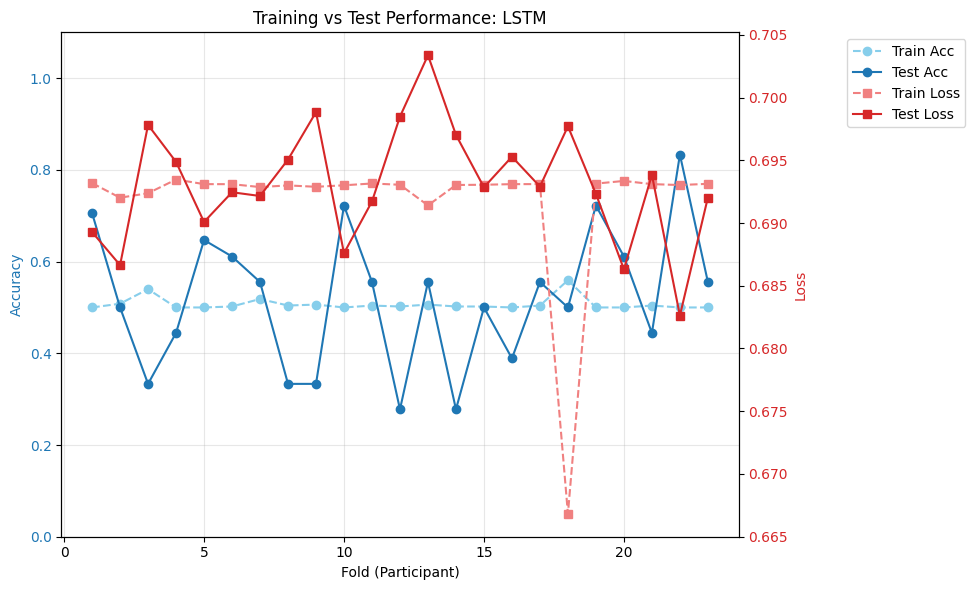

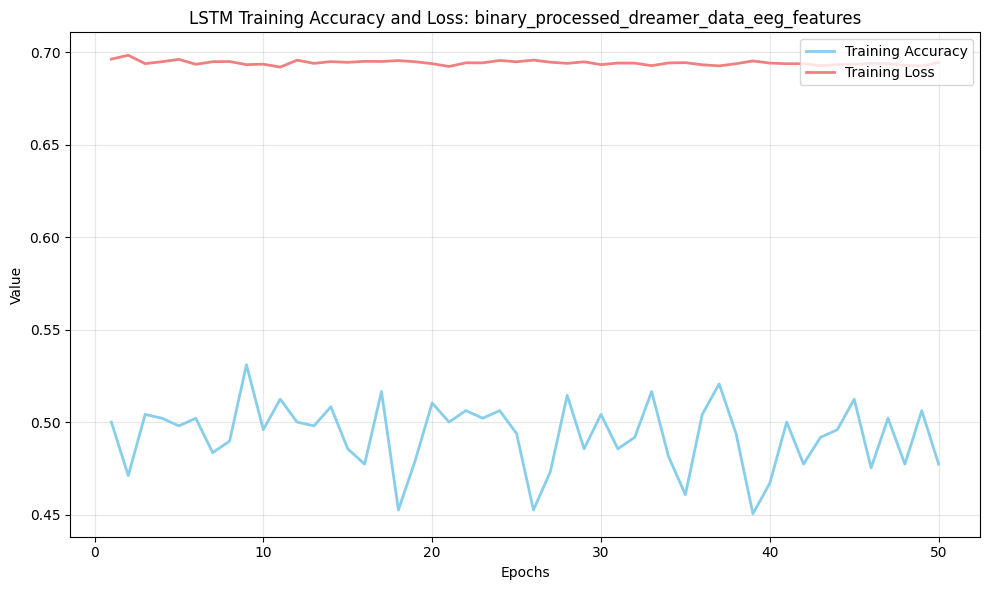

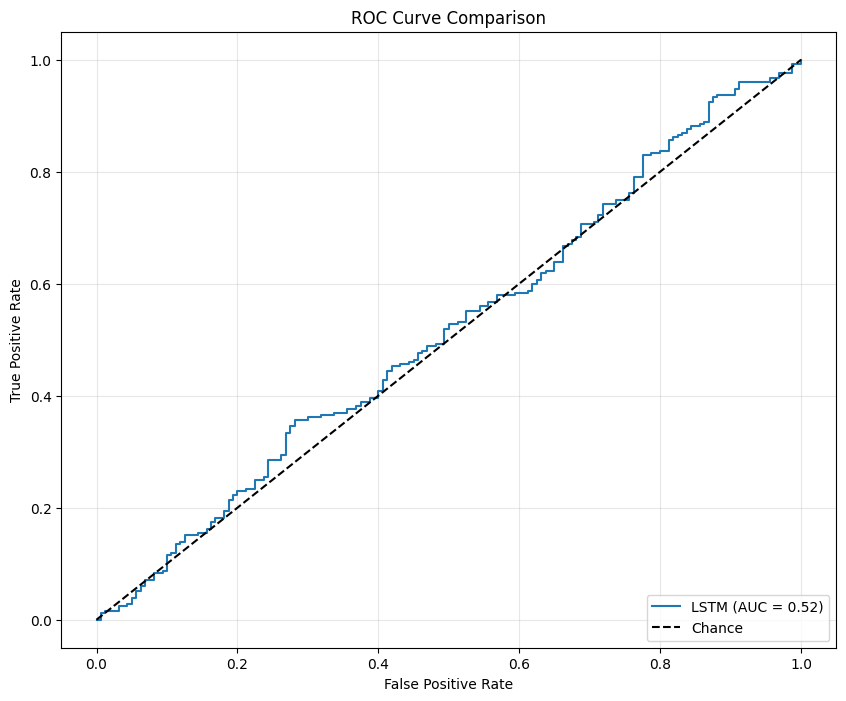

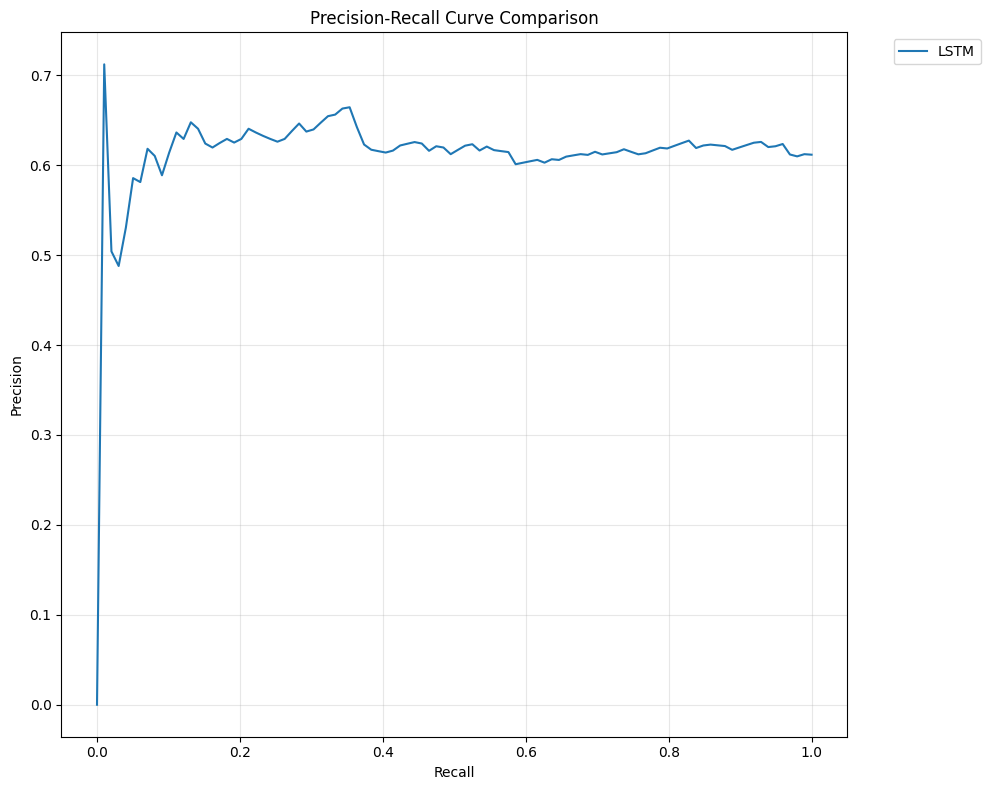

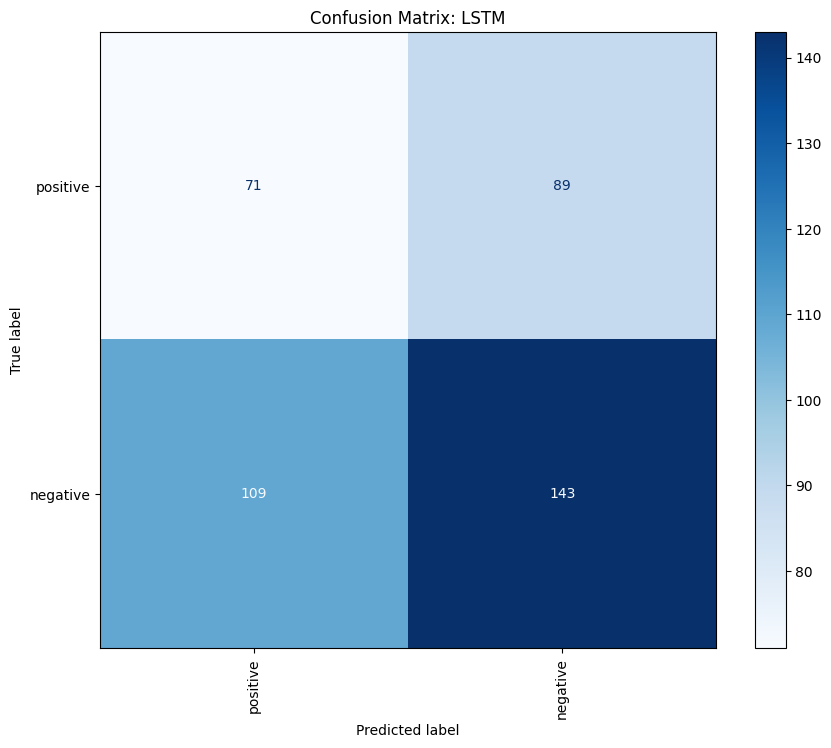

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.35
LSTM -> Train Loss: 1.10
LSTM -> Test Accuracy: 0.47 
LSTM -> Test Loss: 1.10
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.34
LSTM -> Train Loss: 1.10
LSTM -> Test Accuracy: 0.39 
LSTM -> Test Loss: 1.10
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

LSTM -> Train Accuracy: 0.36
LSTM -> Train Loss: 1.09
LSTM -> Test Accuracy: 0.28 
LSTM -> Test Loss: 1.10
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.34
LSTM -> Train Loss: 1.09
LSTM -> Test Accuracy: 0.28 
LSTM -> Test Loss: 1.13
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.35
LSTM -> Train Loss: 1.10
LSTM -> Test Accuracy: 0.11 
LSTM -> Test Loss: 1.10

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.348387       1.098128       0.470588   1.096321  LSTM
1            0.335456       1.097693       0.388889   1.100552  LSTM
2            0.354701       1.095037       0.222222   1.120591  LSTM
3            0.392405       1.091173       0.277778   1.135390  LSTM
4            0.344017       1.098052       0.352941   1.101386  LSTM
5            0.339827       1.098297       0.333333   1.098635  LSTM
6            0.337580       1.096841       0.166667   1.108572  LSTM
7            0.335470       1.098115       0.222222   1.107420  LSTM
8            0.337634       1.098373       0.277778   1.102430  LSTM
9            0.335470       1.096152       0.111111   1.107455  LSTM
10           0.384615       1.094919       0.222222   1.121070  LSTM
11           0.369892       1.094028       0.333

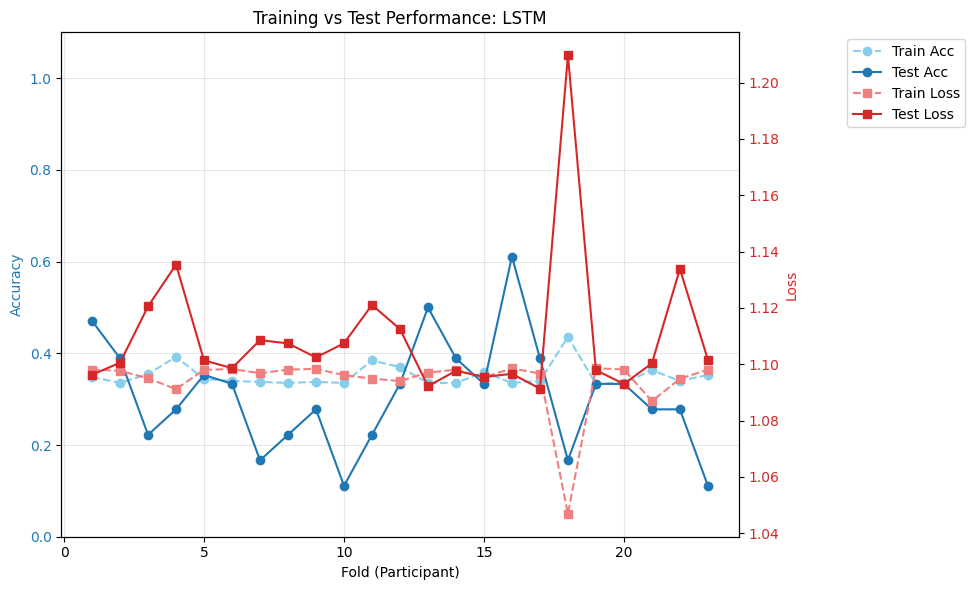

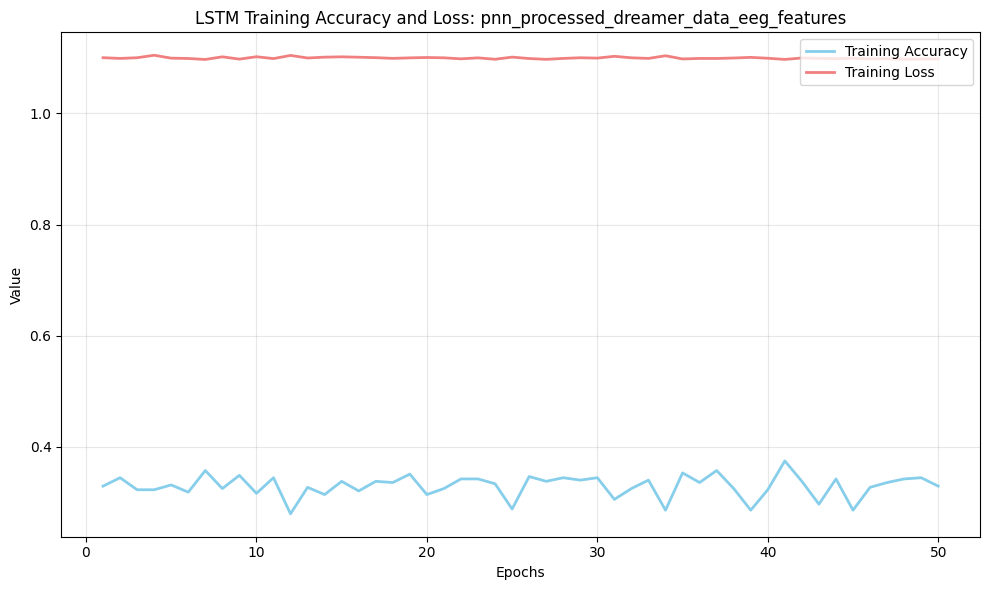

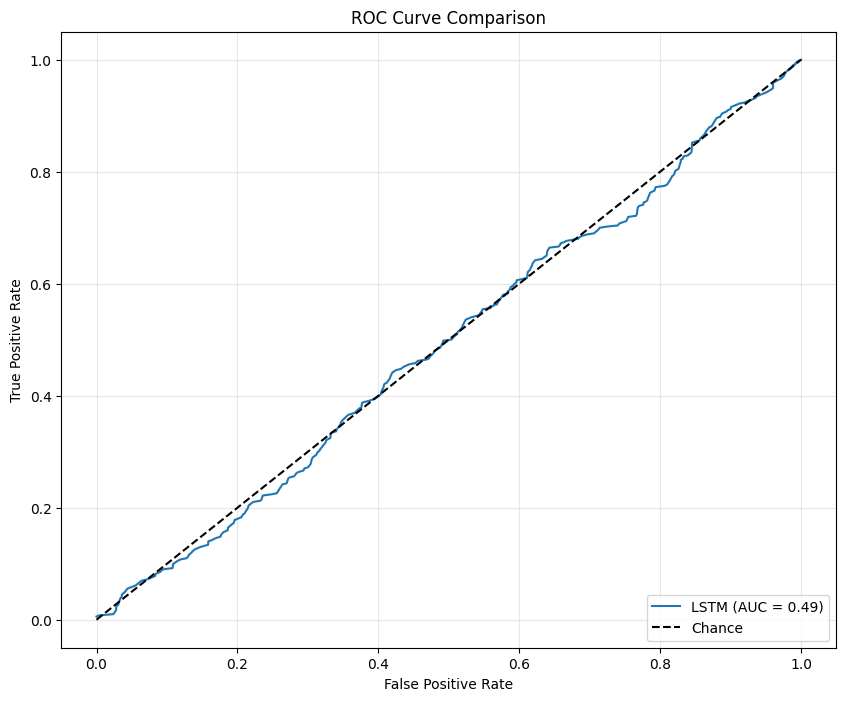

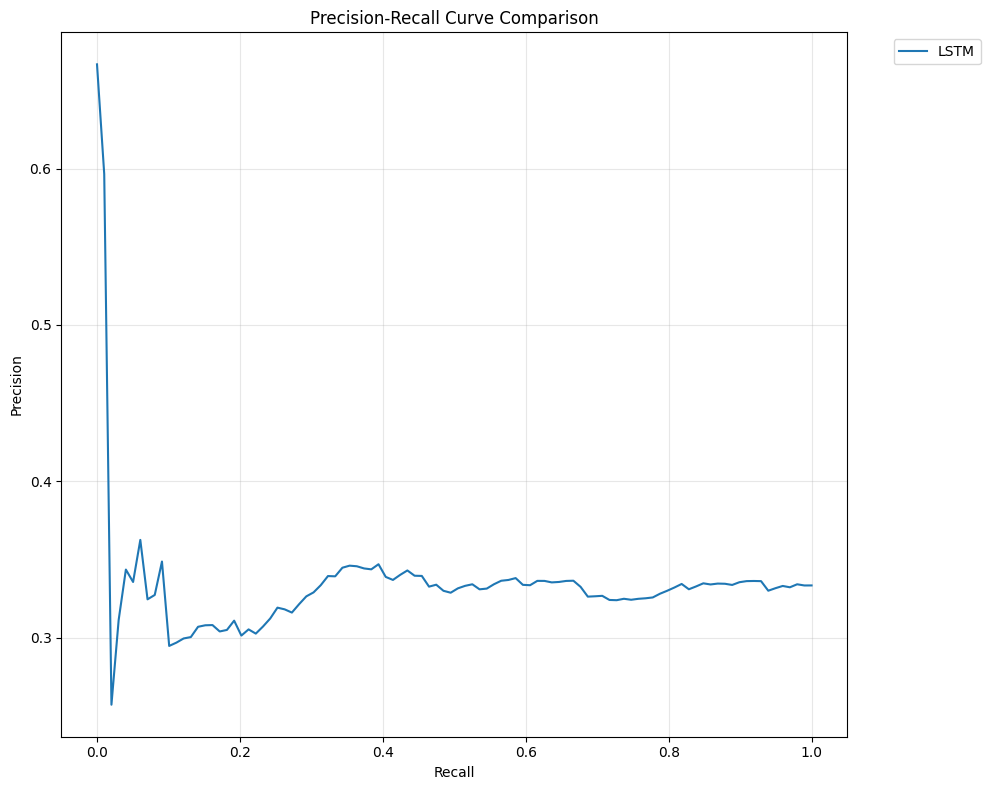

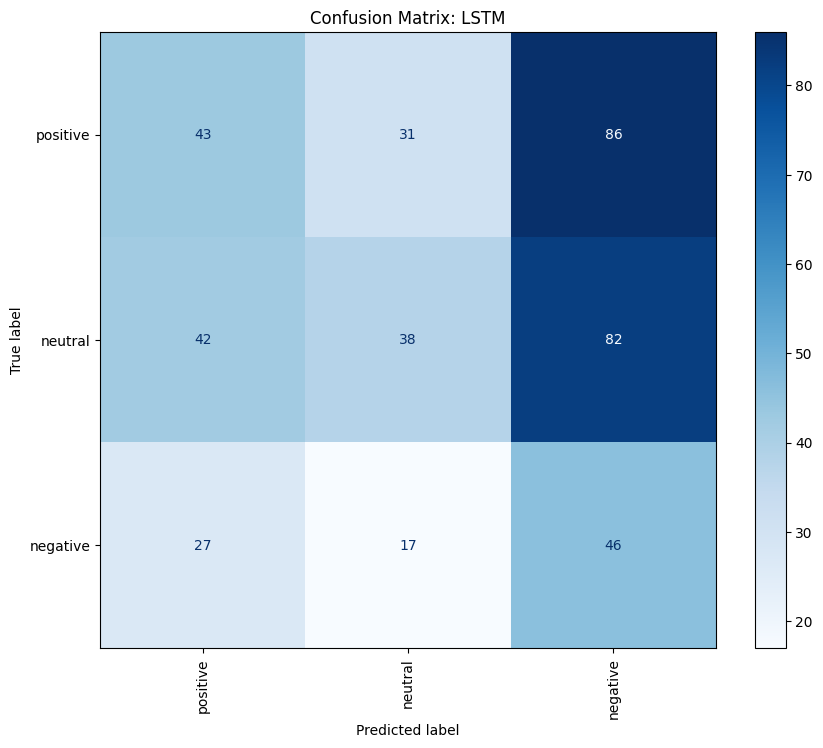

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.25
LSTM -> Train Loss: 1.39
LSTM -> Test Accuracy: 0.35 
LSTM -> Test Loss: 1.37
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.26
LSTM -> Train Loss: 1.39
LSTM -> Test Accuracy: 0.33 
LSTM -> Test Loss: 1.38
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

LSTM -> Train Accuracy: 0.30
LSTM -> Train Loss: 1.38
LSTM -> Test Accuracy: 0.17 
LSTM -> Test Loss: 1.39
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.25
LSTM -> Train Loss: 1.39
LSTM -> Test Accuracy: 0.06 
LSTM -> Test Loss: 1.39
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.25
LSTM -> Train Loss: 1.39
LSTM -> Test Accuracy: 0.33 
LSTM -> Test Loss: 1.38

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.250000       1.385615       0.352941   1.373006  LSTM
1            0.255396       1.385823       0.333333   1.377982  LSTM
2            0.269784       1.383237       0.166667   1.402121  LSTM
3            0.264925       1.374656       0.333333   1.373680  LSTM
4            0.264286       1.382662       0.294118   1.392084  LSTM
5            0.281690       1.380825       0.111111   1.397545  LSTM
6            0.250000       1.385709       0.388889   1.379961  LSTM
7            0.283088       1.385639       0.222222   1.388498  LSTM
8            0.290493       1.382357       0.277778   1.386620  LSTM
9            0.273381       1.383926       0.277778   1.388585  LSTM
10           0.251825       1.385866       0.388889   1.372511  LSTM
11           0.278369       1.385615       0.166

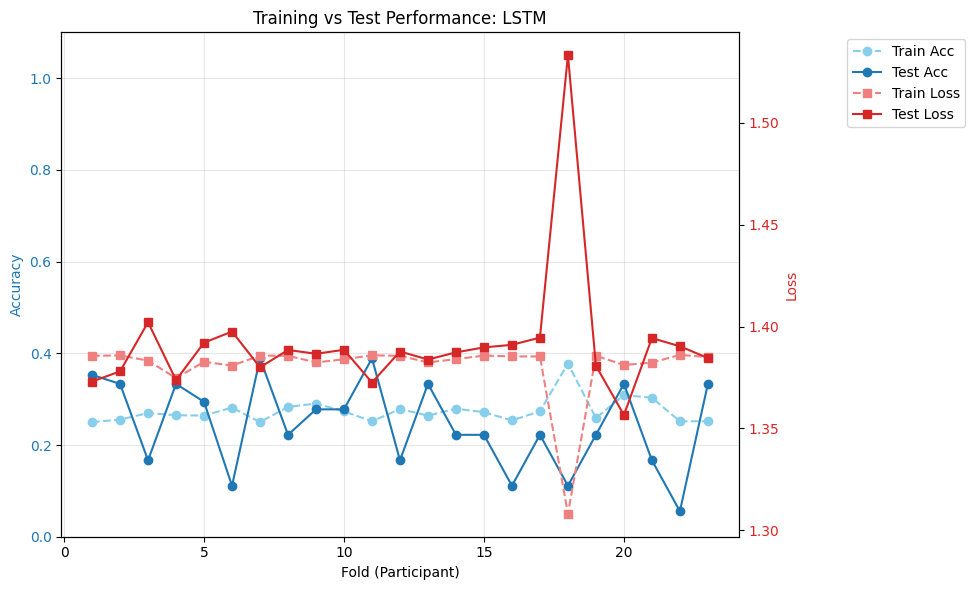

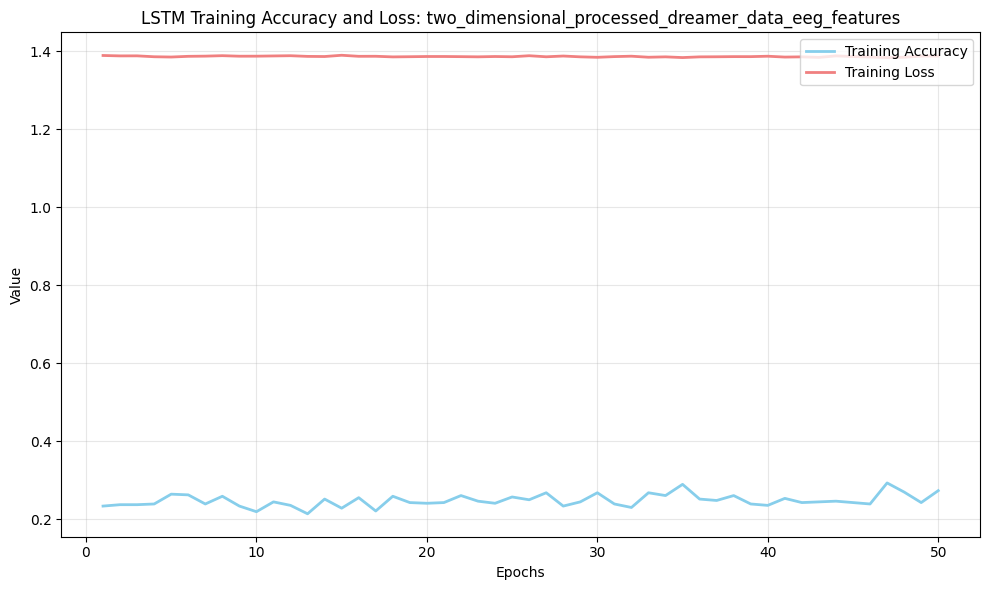

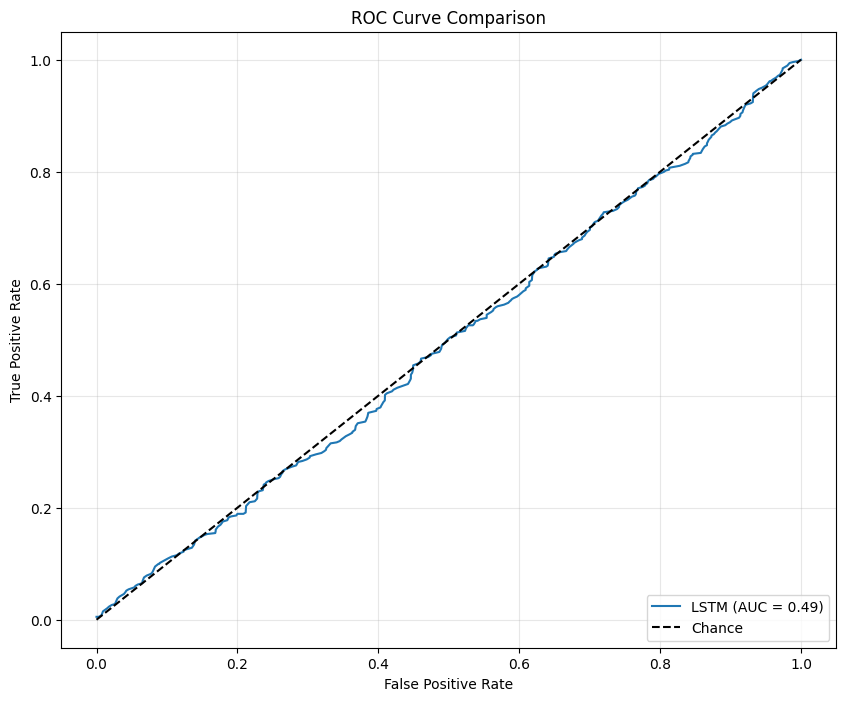

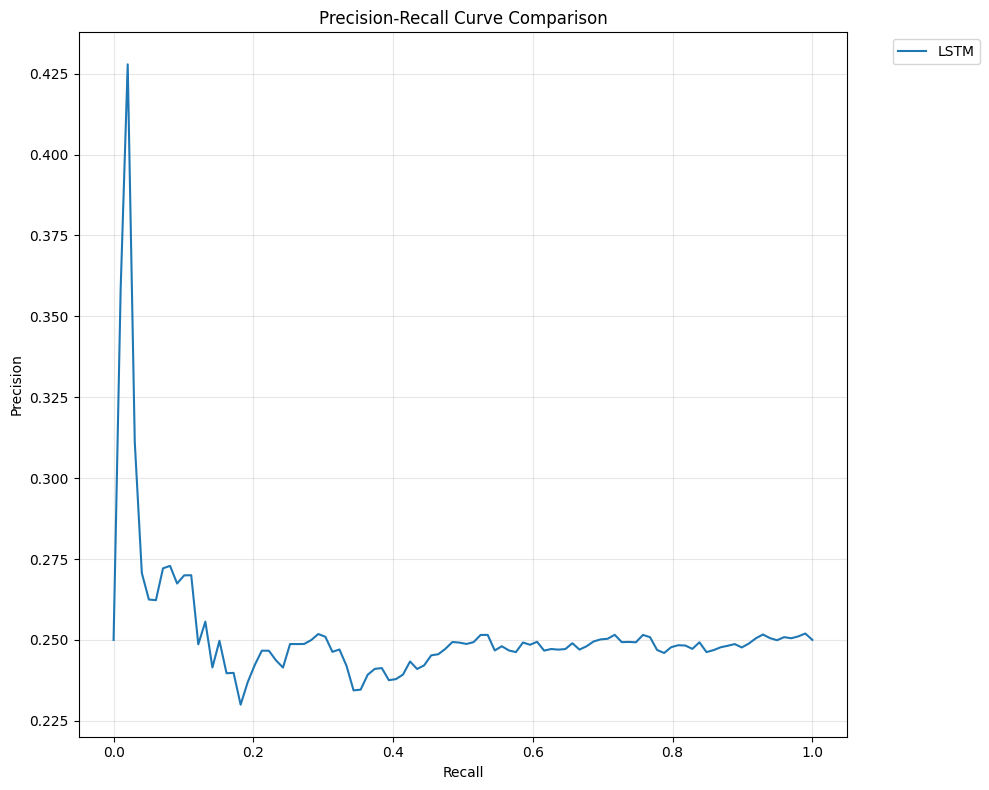

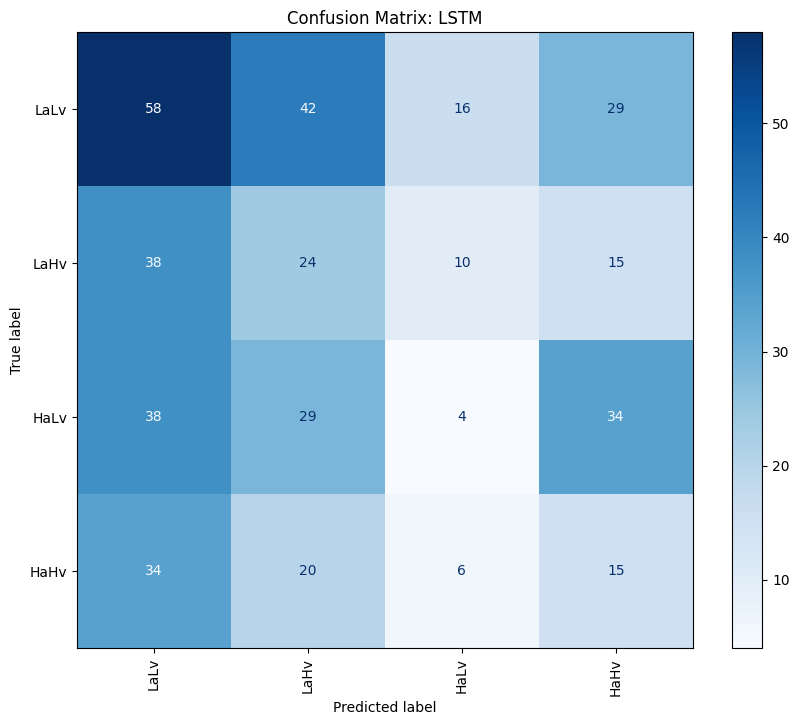

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.11
LSTM -> Train Loss: 2.20
LSTM -> Test Accuracy: 0.24 
LSTM -> Test Loss: 2.20
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.11
LSTM -> Train Loss: 2.20
LSTM -> Test Accuracy: 0.06 
LSTM -> Test Loss: 2.20
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.13
LSTM -> Train Loss: 2.20
LSTM -> Test Accuracy: 0.11 
LSTM -> Test Loss: 2.20
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.11
LSTM -> Train Loss: 2.19
LSTM -> Test Accuracy: 0.17 
LSTM -> Test Loss: 2.20

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.111111       2.197279       0.235294   2.197315  LSTM
1            0.111111       2.196956       0.055556   2.201192  LSTM
2            0.119342       2.195595       0.111111   2.209348  LSTM
3            0.109722       2.197155       0.055556   2.196783  LSTM
4            0.111111       2.197254       0.294118   2.194338  LSTM
5            0.113960       2.197022       0.222222   2.198311  LSTM
6            0.111111       2.197157       0.222222   2.192065  LSTM
7            0.116466       2.196308       0.166667   2.195157  LSTM
8            0.111111       2.197576       0.055556   2.222024  LSTM
9            0.111111       2.196904       0.388889   2.192153  LSTM
10           0.111111       2.197256       0.000000   2.199157  LSTM
11           0.158931       2.185626       0.166

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


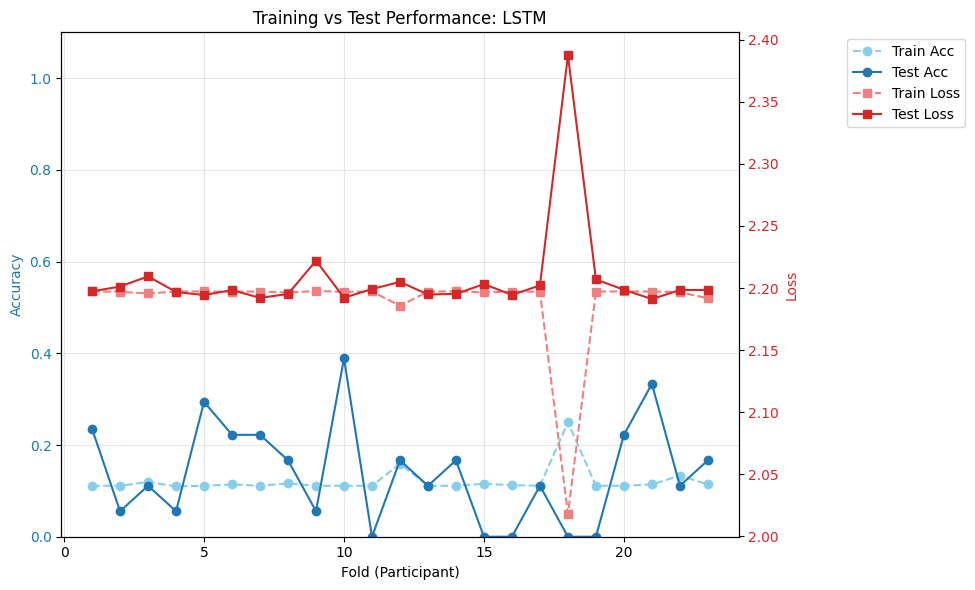

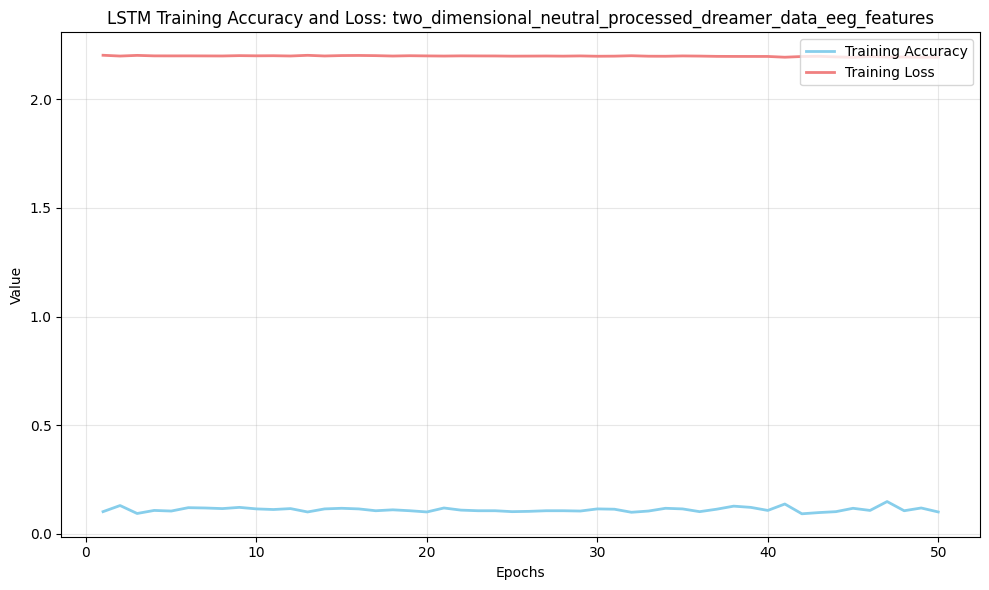

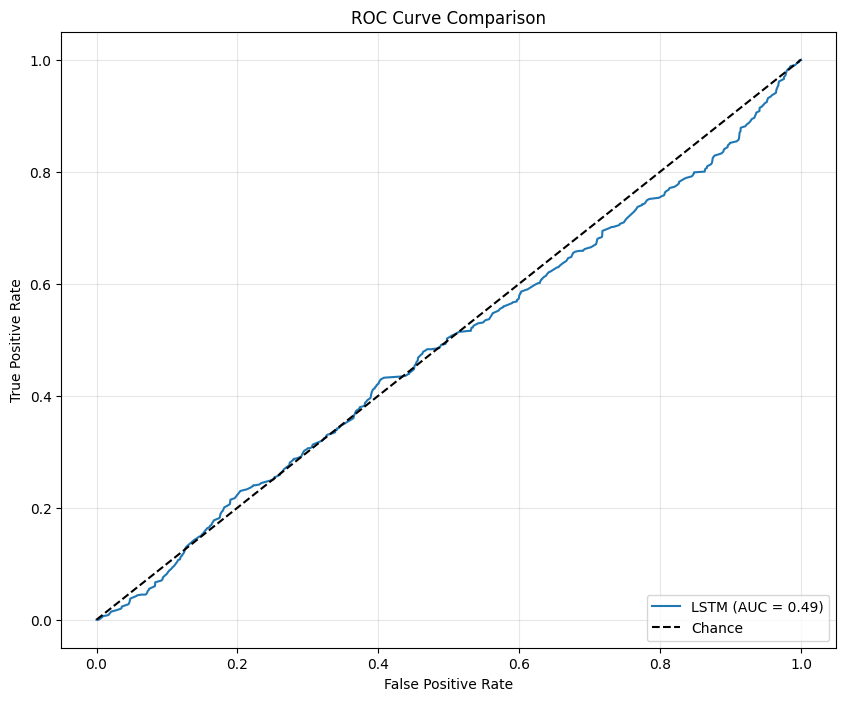

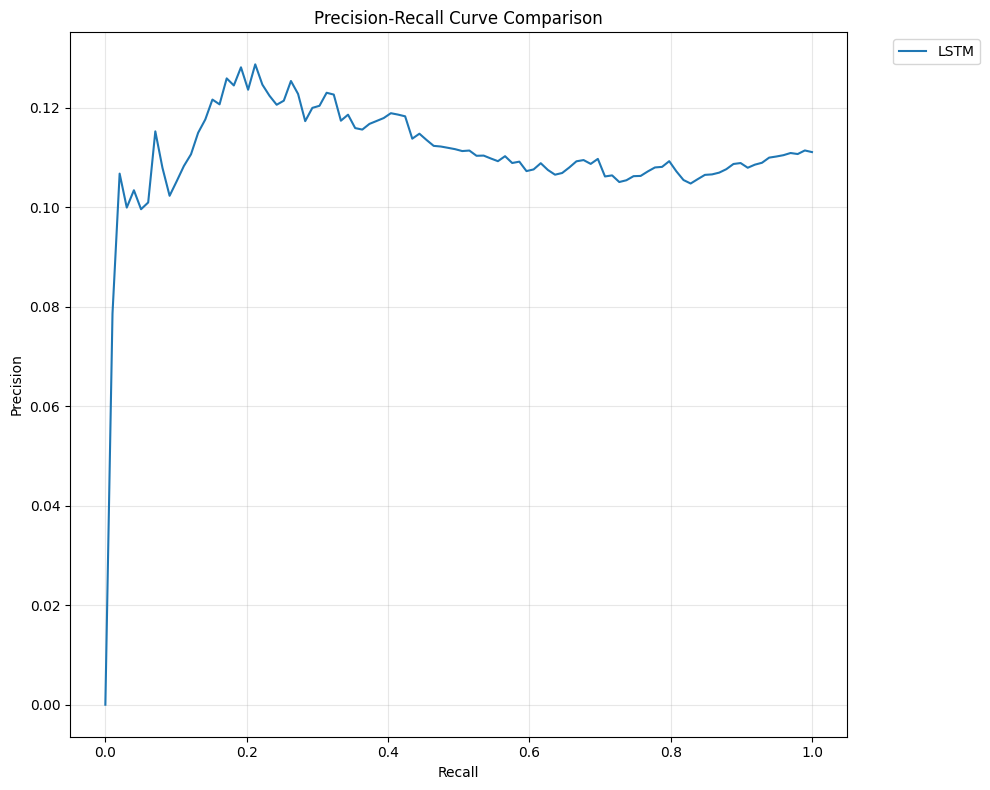

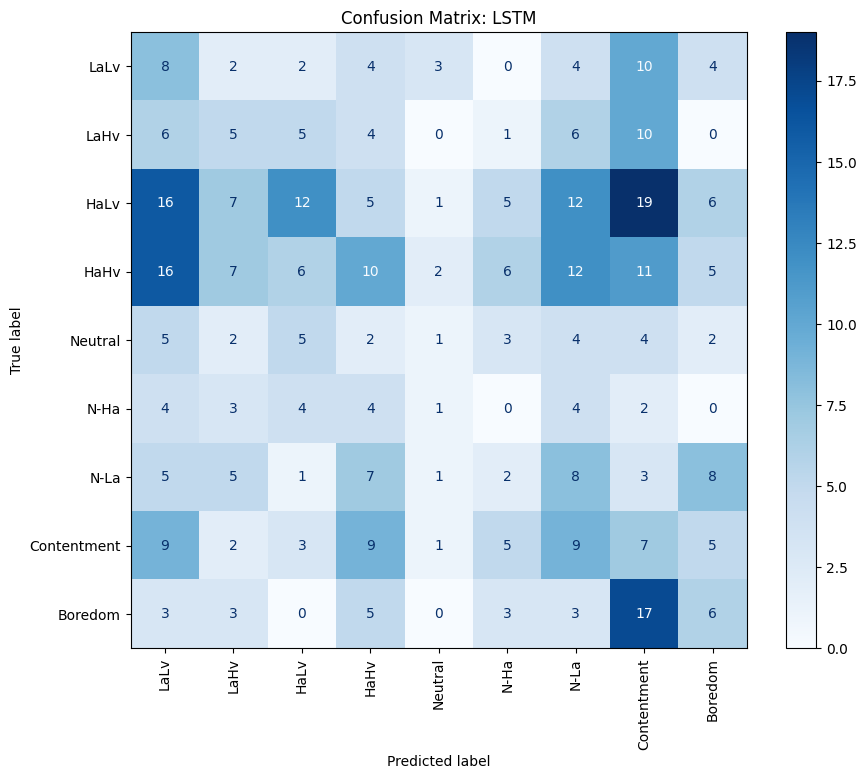

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super()

LSTM -> Train Accuracy: 0.15
LSTM -> Train Loss: 2.08
LSTM -> Test Accuracy: 0.12 
LSTM -> Test Loss: 2.08
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM -> Train Accuracy: 0.12
LSTM -> Train Loss: 2.08
LSTM -> Test Accuracy: 0.06 
LSTM -> Test Loss: 2.08
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

LSTM -> Train Accuracy: 0.12
LSTM -> Train Loss: 2.08
LSTM -> Test Accuracy: 0.06 
LSTM -> Test Loss: 2.08
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.12
LSTM -> Train Loss: 2.08
LSTM -> Test Accuracy: 0.00 
LSTM -> Test Loss: 2.08
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.13
LSTM -> Train Loss: 2.08
LSTM -> Test Accuracy: 0.11 
LSTM -> Test Loss: 2.07

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.153935       2.079049       0.117647   2.080911  LSTM
1            0.125000       2.079129       0.055556   2.076661  LSTM
2            0.125000       2.078346       0.166667   2.081871  LSTM
3            0.123775       2.079255       0.055556   2.077063  LSTM
4            0.126157       2.079450       0.058824   2.080722  LSTM
5            0.125000       2.079328       0.000000   2.066965  LSTM
6            0.125000       2.079113       0.277778   2.074320  LSTM
7            0.127404       2.079242       0.166667   2.090400  LSTM
8            0.126147       2.079308       0.166667   2.078016  LSTM
9            0.126168       2.078750       0.277778   2.071832  LSTM
10           0.125000       2.079115       0.166667   2.074396  LSTM
11           0.143349       2.079372       0.166

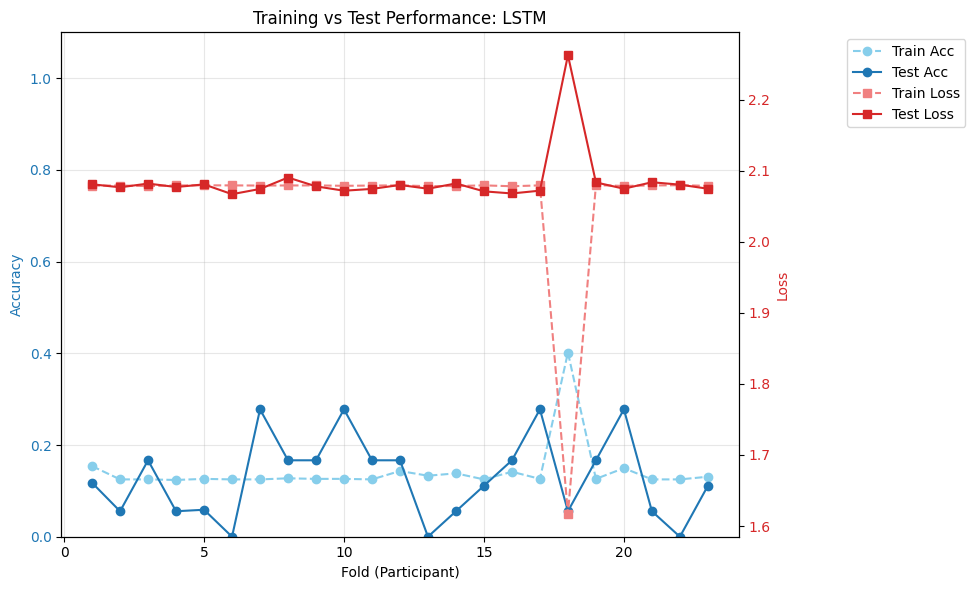

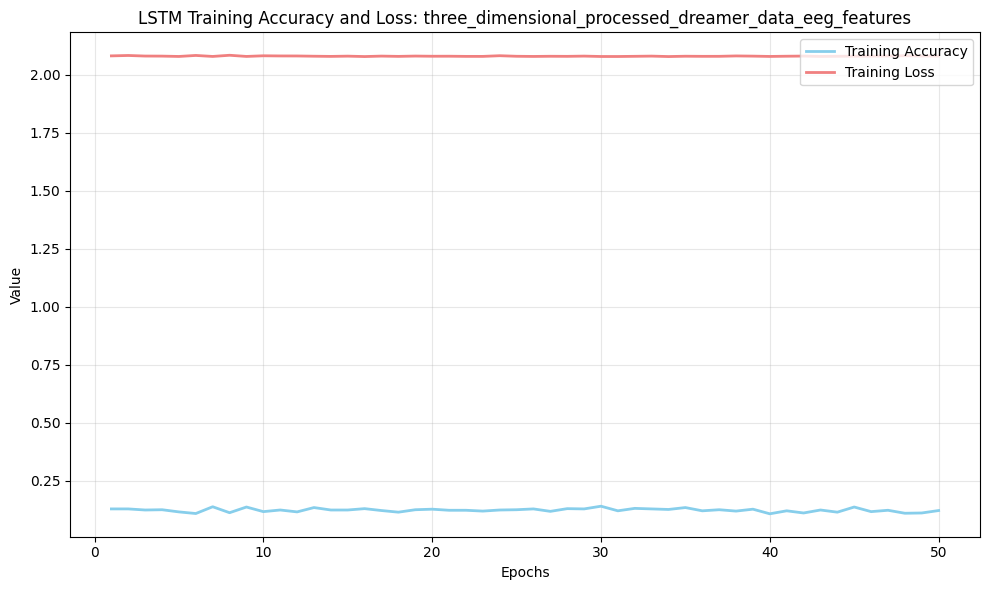

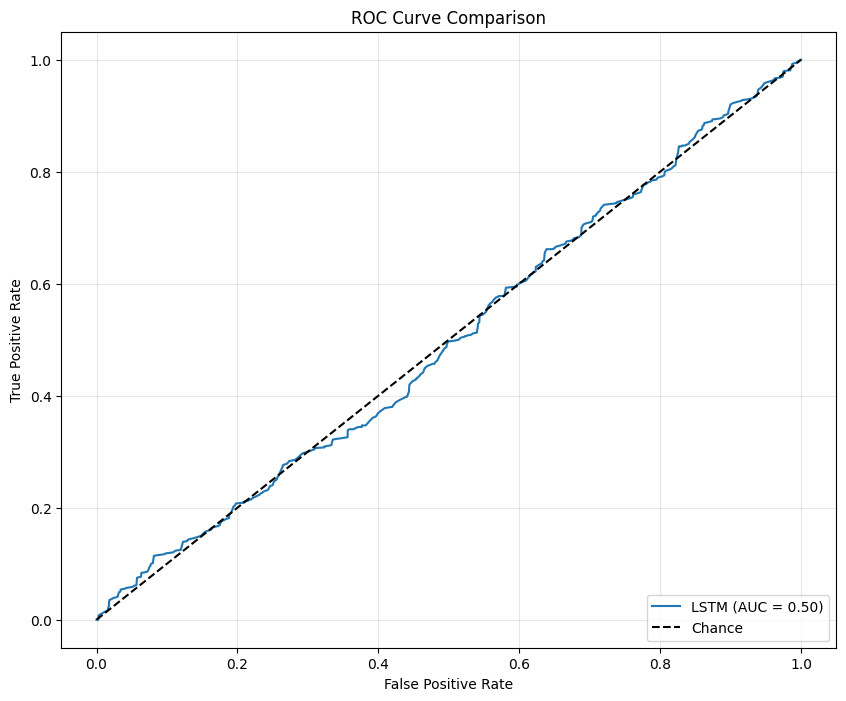

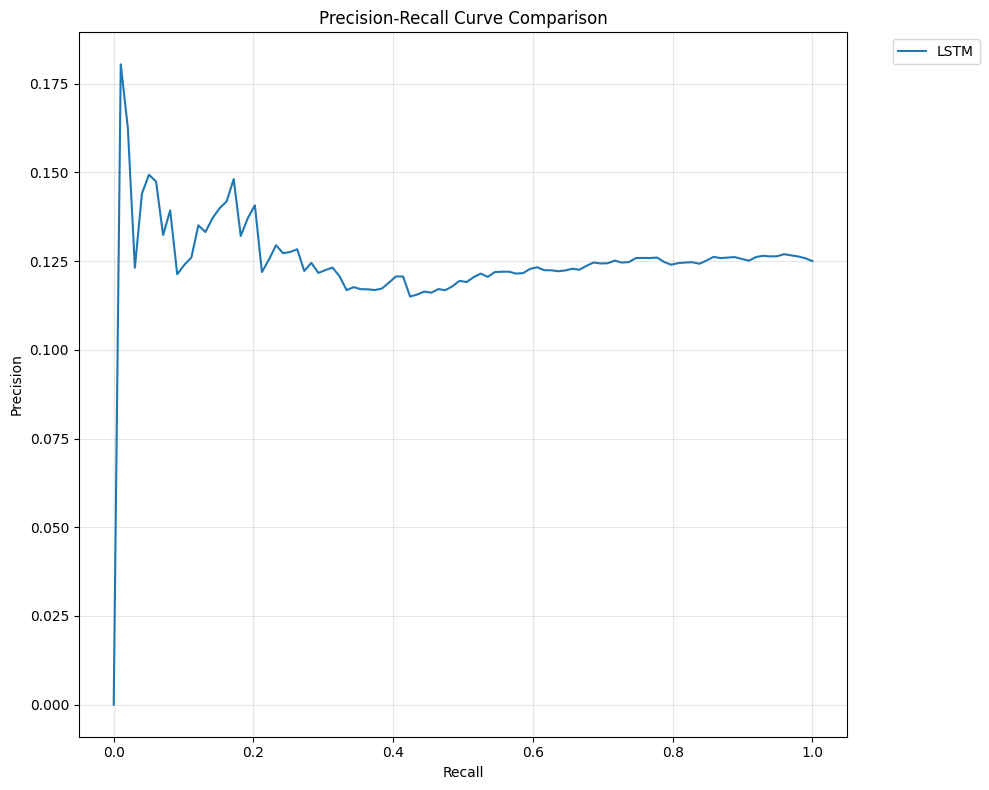

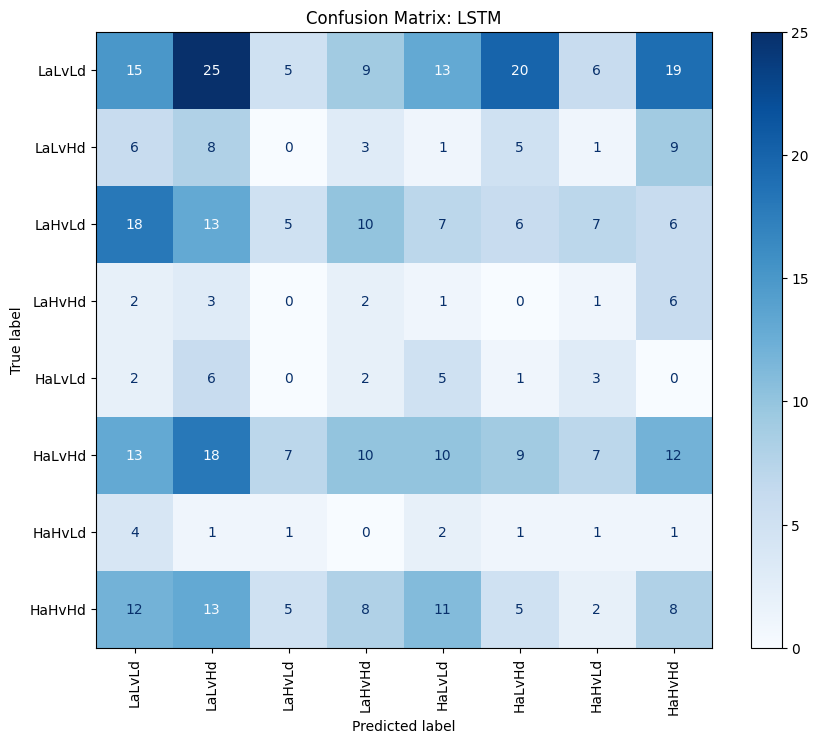

     eeg_alpha_0  eeg_beta_0  eeg_theta_0  eeg_alpha_1  eeg_beta_1  \
0       0.067790    0.047957     0.150838     0.067790    0.047957   
1       0.090884    0.097723     0.112210     0.090884    0.097723   
2       0.193396    0.220671     0.261638     0.255804    0.248341   
3       0.332105    0.670633     0.398959     0.304380    0.480546   
4       0.121810    0.064467     0.513176     0.192413    0.114410   
..           ...         ...          ...          ...         ...   
407     0.187366    0.102705     0.254771     0.224419    0.121683   
408     0.258699    0.159136     0.256964     0.256758    0.136273   
409     0.130435    0.128093     0.205357     0.122276    0.112370   
410     0.322682    0.278605     0.389938     0.260144    0.200331   
411     0.248083    0.194229     0.581144     0.111164    0.103517   

     eeg_theta_1  eeg_alpha_2  eeg_beta_2  eeg_theta_2  eeg_alpha_3  ...  \
0       0.150838     0.067790    0.047957     0.150838     0.067790  ...   
1      

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.14
LSTM -> Train Loss: 2.89
LSTM -> Test Accuracy: 0.00 
LSTM -> Test Loss: 3.53
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.28
LSTM -> Train Loss: 2.53
LSTM -> Test Accuracy: 0.06 
LSTM -> Test Loss: 4.18
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 2

...

LSTM -> Train Accuracy: 0.26
LSTM -> Train Loss: 2.60
LSTM -> Test Accuracy: 0.00 
LSTM -> Test Loss: 4.91
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.31
LSTM -> Train Loss: 2.55
LSTM -> Test Accuracy: 0.00 
LSTM -> Test Loss: 4.82
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 2

C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\seanl\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


LSTM -> Train Accuracy: 0.28
LSTM -> Train Loss: 2.55
LSTM -> Test Accuracy: 0.00 
LSTM -> Test Loss: 5.53

--Final Results
    Training Accuracy  Training Loss  Test Accuracy  Test Loss model
0            0.137053       2.887751       0.000000   3.529442  LSTM
1            0.284156       2.530838       0.055556   4.178429  LSTM
2            0.181143       2.731261       0.000000   7.671528  LSTM
3            0.249451       2.509376       0.000000   5.111101  LSTM
4            0.251131       2.607696       0.000000   3.822822  LSTM
5            0.194604       2.679754       0.000000   3.824206  LSTM
6            0.264638       2.580705       0.055556   4.418870  LSTM
7            0.206731       2.561950       0.055556   4.070239  LSTM
8            0.306544       2.558871       0.055556   4.329295  LSTM
9            0.259615       2.581707       0.055556   3.997881  LSTM
10           0.239253       2.660987       0.055556   3.957494  LSTM
11           0.213736       2.799235       0.000

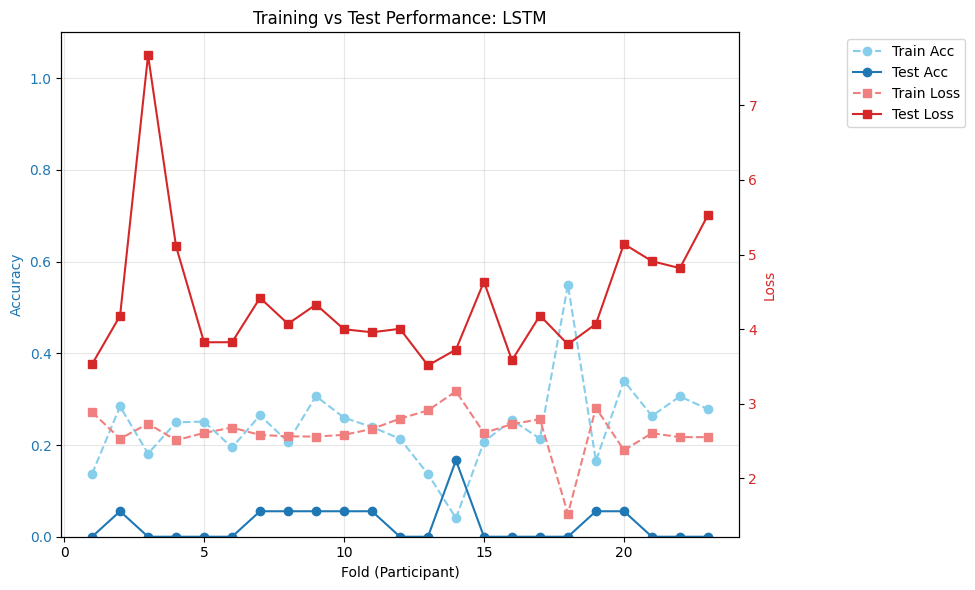

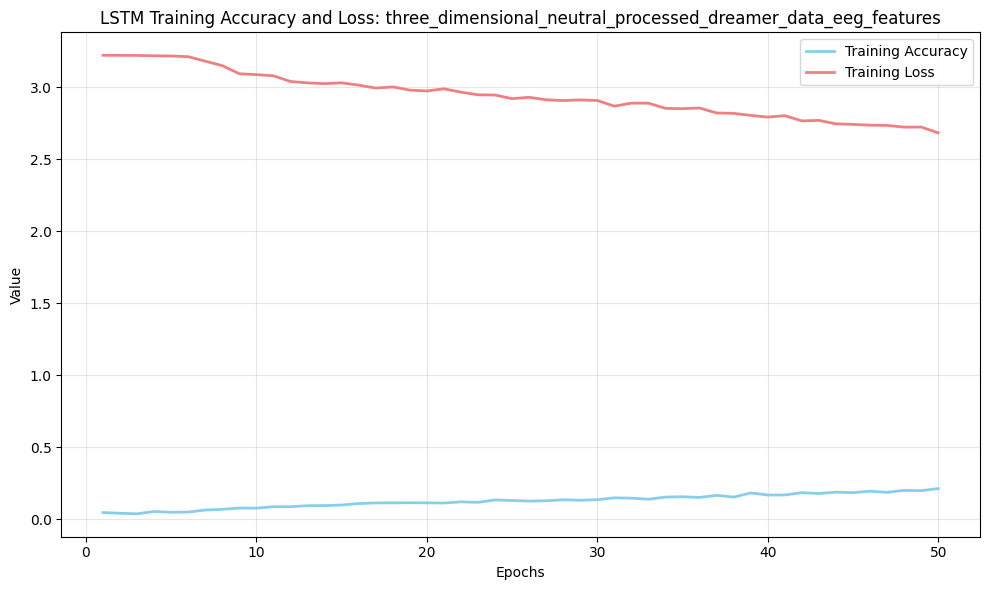

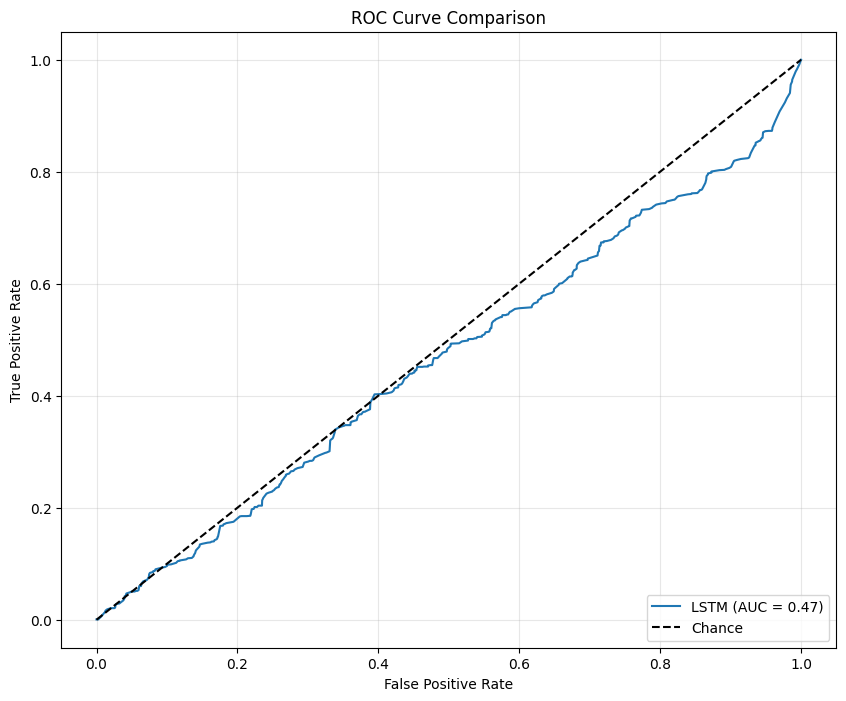

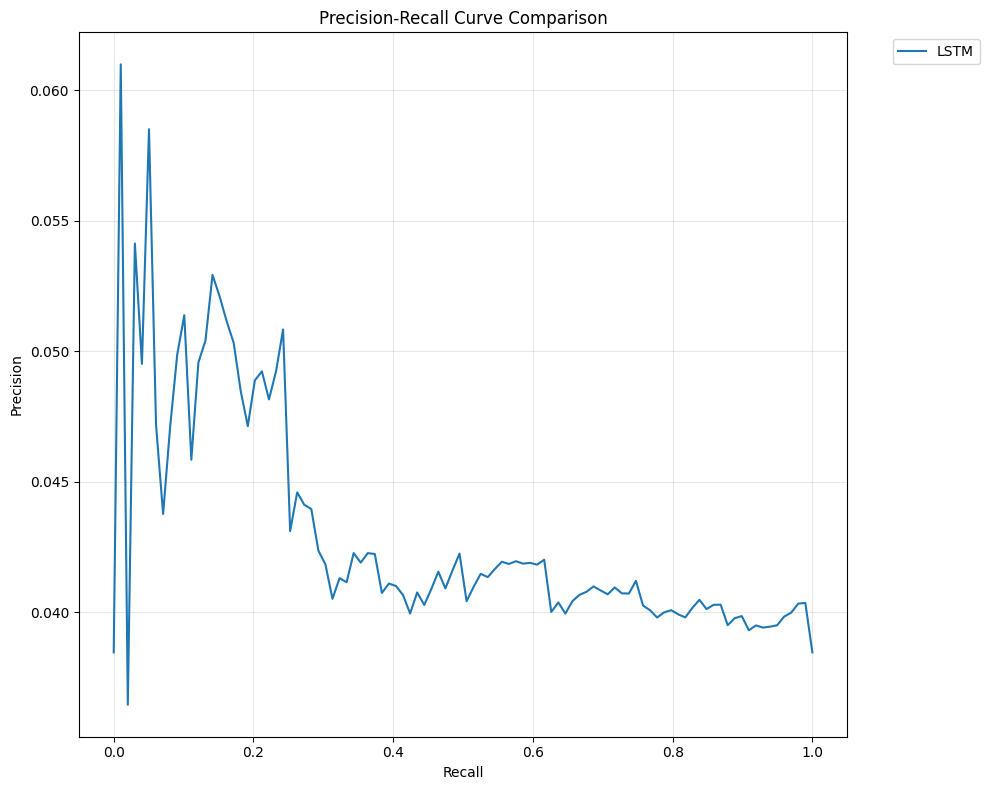

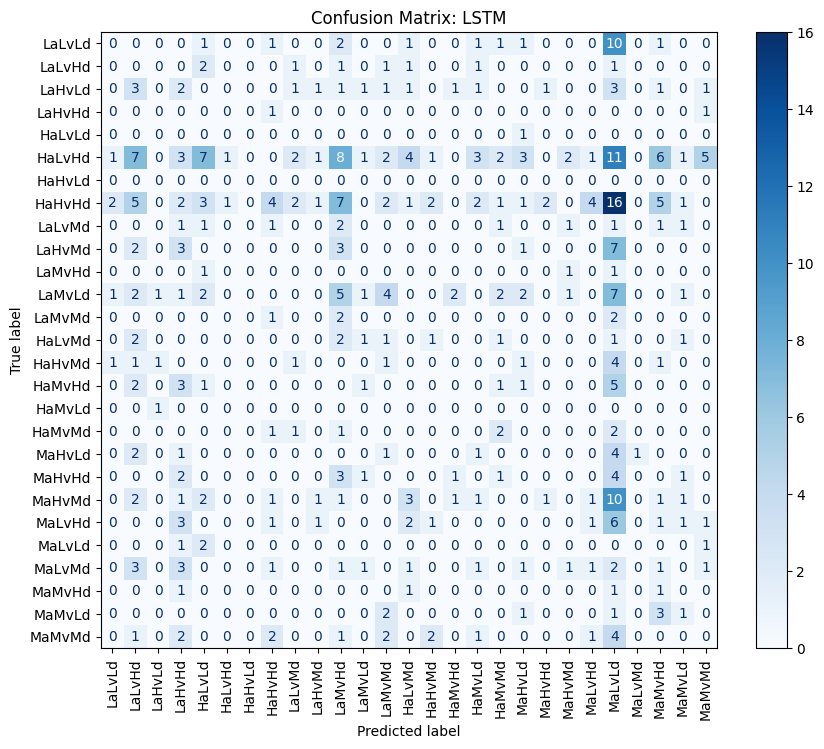

In [ ]:
def main():
    dir_path = r"C:\Users\seanl\Desktop\DREAMER_EXPERIMENT"
    file_names = ["processed_dreamer_data_eeg_features.csv", "processed_dreamer_data_ecg_features.csv", "processed_dreamer_data_fused_features.csv"]
    file_name = file_names[1] # change index to switch dataset: 0=EEG, 1=ECG, 2=Fused

    binary_emotion_class = {"positive": 1, "negative": 0}
    pnn_emotion_class = {"positive": 1, "neutral": 2, "negative": 0}
    two_dimensional_emotion_class = {"LaLv": 0, "LaHv": 1, "HaLv": 2, "HaHv": 3}
    two_dimensional_emotion_class_neutral = {"LaLv": 0, "LaHv": 1, "HaLv": 2, "HaHv": 3, "Neutral": 4, "N-Ha": 5, "N-La": 6, "Contentment": 7, "Boredom": 8}
    three_dimensional_emotion_class = {"LaLvLd": 0, "LaLvHd": 1, "LaHvLd": 2, "LaHvHd": 3, "HaLvLd": 4, "HaLvHd": 5, "HaHvLd": 6, "HaHvHd": 7}
    three_dimensional_emotion_class_neutral = {"LaLvLd": 0, "LaLvHd": 1, "LaHvLd": 2, "LaHvHd": 3, "HaLvLd": 4, "HaLvHd": 5, "HaHvLd": 6, "HaHvHd": 7,
                                               "LaLvMd": 8, "LaHvMd": 9, "LaMvHd": 10, "LaMvLd": 11, "LaMvMd": 12, "HaLvMd": 13, "HaHvMd": 14, "HaMvHd": 15,
                                               "HaMvLd": 16, "HaMvMd": 17, "MaHvLd": 18, "MaHvHd": 19, "MaHvMd": 20, "MaLvHd": 21, "MaLvLd": 22, "MaLvMd": 23,
                                               "MaMvHd": 24, "MaMvLd": 25, "MaMvMd": 26}
  
    emotion_class_types = ['binary', 'pnn', 'two_dimensional', 'two_dimensional_neutral', 'three_dimensional', 'three_dimensional_neutral']
    emotion_classes = [binary_emotion_class, pnn_emotion_class, two_dimensional_emotion_class, two_dimensional_emotion_class_neutral, three_dimensional_emotion_class, three_dimensional_emotion_class_neutral]

    models = {#"Dummy": DummyClassifier(strategy = "stratified", random_state=random.seed(42)),
              #"SVM": SVC(kernel="rbf", C=0.01, probability=True),
              #"Random Forest": RandomForestClassifier(random_state=random.seed(42), n_jobs= -1, max_depth=2, min_samples_leaf=2,
                                                      #n_estimators=2, class_weight = 'balanced_subsample'),
              #"kNN": KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2),
              #"Decision Tree": DecisionTreeClassifier(criterion = "log_loss", splitter = "best", max_depth=2, max_leaf_nodes=2,
                                                      #min_samples_leaf=2,random_state=random.seed(42)),
              #"Logistic Regression": LogisticRegression(max_iter=10000, solver="newton-cg", C=0.05, n_jobs=-1, penalty='l2'),
              #"Gaussian NB": GaussianNB(),
              #"XGboost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, use_label_encoder=False, 
                                       #eval_metric='logloss'),
              #"AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42),
              "LSTM": LSTMModel(epochs=50, batch_size=32, learning_rate=0.001)
           }


    dreamer_data_df = load_data_file(dir_path, file_name)

    print(dreamer_data_df)
    print(dreamer_data_df.columns)
    print(dreamer_data_df.shape)
    print(dreamer_data_df.head())

    valences, arousals, dominances, videos, participants = extract_labels_video_participant(dreamer_data_df)
    print(f"valences: {valences}")
    print(f"arousals: {arousals}")
    print(f"dominances: {dominances}")
    print(f"videos: {videos}")
    print(f"participants: {participants}")
    print(len(valences), len(arousals), len(dominances), len(videos), len(participants))

    features = extract_signal_features(dreamer_data_df)
    print(features)
    print(features.shape)

    num_classes = len(emotion_classes)
    for iclass in range(num_classes):
      create_emotion_label(valences, arousals, dominances, dreamer_data_df, emotion_class_types, emotion_class_types[iclass], emotion_classes)
      print(dreamer_data_df)

      if iclass == num_classes - 1:
        models = {#"Dummy": DummyClassifier(strategy = "stratified", random_state=random.seed(42)),
              #"SVM": SVC(kernel="rbf", C=0.01, probability=True),
              #"Random Forest": RandomForestClassifier(random_state=random.seed(42), n_jobs= -1, max_depth=2, min_samples_leaf=2,
                                                      #n_estimators=2, class_weight = 'balanced_subsample'),
              #"kNN": KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2),
              #"Decision Tree": DecisionTreeClassifier(criterion = "log_loss", splitter = "best", max_depth=2, max_leaf_nodes=2,
                                                      #min_samples_leaf=2,random_state=random.seed(42)),
              #"Logistic Regression": LogisticRegression(max_iter=10000, solver="newton-cg", C=0.05, n_jobs=-1, penalty='l2'),
              #"Gaussian NB": GaussianNB(),
              #"AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42),
              "LSTM": LSTMModel(epochs=50, batch_size=32, learning_rate=0.001)
           }
        #results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation(dreamer_data_df, models, emotion_classes[iclass])
        results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation_balanced(dreamer_data_df, models, emotion_classes[iclass])
      else:
        #results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation(dreamer_data_df, models)
        results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation_balanced(dreamer_data_df, models)
     
      print("\n--Final Results")
      print(results_df)
      print("\n--Final Summary (Global Metrics)")
      print(summary_df)

      plot_acc_loss_graph_one_classifier(results_df)
      plot_lstm_epoch_curves(
            models["LSTM"],
            f"{emotion_class_types[iclass]}_{file_name.replace('.csv','')}",
            dir_path
        )
      plot_multiclass_roc(plot_data, all_classes)
      plot_precision_recall_curve(plot_data, all_classes) 
      plot_all_confusion_matrices(plot_data, all_classes,emotion_classes[iclass].keys())

if __name__=="__main__":
    main()

In [69]:
def main():
    dir_path = "/content/drive/MyDrive/dataset/subject_independent"
    file_names = ["processed_dreamer_data_eeg_features_participant12.csv", "processed_dreamer_data_ecg_features_participant3.csv", "processed_dreamer_data_fused_features.csv"]
    file_name = file_names[2]

    binary_emotion_class = {"positive": 1, "negative": 0}
    pnn_emotion_class = {"positive": 1, "neutral": 2, "negative": 0}
    two_dimensional_emotion_class = {"LaLv": 0, "LaHv": 1, "HaLv": 2, "HaHv": 3}
    two_dimensional_emotion_class_neutral = {"LaLv": 0, "LaHv": 1, "HaLv": 2, "HaHv": 3, "Neutral": 4, "N-Ha": 5, "N-La": 6, "Contentment": 7, "Boredom": 8}
    three_dimensional_emotion_class = {"LaLvLd": 0, "LaLvHd": 1, "LaHvLd": 2, "LaHvHd": 3, "HaLvLd": 4, "HaLvHd": 5, "HaHvLd": 6, "HaHvHd": 7}
    three_dimensional_emotion_class_neutral = {"LaLvLd": 0, "LaLvHd": 1, "LaHvLd": 2, "LaHvHd": 3, "HaLvLd": 4, "HaLvHd": 5, "HaHvLd": 6, "HaHvHd": 7,
                                               "LaLvMd": 8, "LaHvMd": 9, "LaMvHd": 10, "LaMvLd": 11, "LaMvMd": 12, "HaLvMd": 13, "HaHvMd": 14, "HaMvHd": 15,
                                               "HaMvLd": 16, "HaMvMd": 17, "MaHvLd": 18, "MaHvHd": 19, "MaHvMd": 20, "MaLvHd": 21, "MaLvLd": 22, "MaLvMd": 23,
                                               "MaMvHd": 24, "MaMvLd": 25, "MaMvMd": 26}
  
    emotion_class_types = ['binary', 'pnn', 'two_dimensional', 'two_dimensional_neutral', 'three_dimensional', 'three_dimensional_neutral']
    emotion_classes = [binary_emotion_class, pnn_emotion_class, two_dimensional_emotion_class, two_dimensional_emotion_class_neutral, three_dimensional_emotion_class, three_dimensional_emotion_class_neutral]

    models = {"Dummy": DummyClassifier(strategy = "stratified", random_state=random.seed(42)),
              "SVM": SVC(kernel="rbf", C=0.01, probability=True),
              "Random Forest": RandomForestClassifier(random_state=random.seed(42), n_jobs= -1, max_depth=2, min_samples_leaf=2,
                                                      n_estimators=2, class_weight = 'balanced_subsample'),
              "kNN": KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2),
              "Decision Tree": DecisionTreeClassifier(criterion = "log_loss", splitter = "best", max_depth=2, max_leaf_nodes=2,
                                                      min_samples_leaf=2,random_state=random.seed(42)),
              "Logistic Regression": LogisticRegression(max_iter=10000, solver="newton-cg", C=0.05, n_jobs=-1, penalty='l2'),
              "Gaussian NB": GaussianNB(),
              "XGboost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, use_label_encoder=False, 
                                       eval_metric='logloss'),
              "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
           }


    dreamer_data_df = load_data_file(dir_path, file_name)

    print(dreamer_data_df)
    print(dreamer_data_df.columns)
    print(dreamer_data_df.shape)
    print(dreamer_data_df.head())

    valences, arousals, dominances, videos, participants = extract_labels_video_participant(dreamer_data_df)
    print(f"valences: {valences}")
    print(f"arousals: {arousals}")
    print(f"dominances: {dominances}")
    print(f"videos: {videos}")
    print(f"participants: {participants}")
    print(len(valences), len(arousals), len(dominances), len(videos), len(participants))

    features = extract_signal_features(dreamer_data_df)
    print(features)
    print(features.shape)

    num_classes = len(emotion_classes)
    for iclass in range(num_classes):
      create_emotion_label(valences, arousals, dominances, dreamer_data_df, emotion_class_types, emotion_class_types[iclass], emotion_classes)
      print(dreamer_data_df)

      if iclass == num_classes - 1:
        models = {"Dummy": DummyClassifier(strategy = "stratified", random_state=random.seed(42)),
              "SVM": SVC(kernel="rbf", C=0.01, probability=True),
              "Random Forest": RandomForestClassifier(random_state=random.seed(42), n_jobs= -1, max_depth=2, min_samples_leaf=2,
                                                      n_estimators=2, class_weight = 'balanced_subsample'),
              "kNN": KNeighborsClassifier(n_neighbors = 7, metric = 'minkowski', p = 2),
              "Decision Tree": DecisionTreeClassifier(criterion = "log_loss", splitter = "best", max_depth=2, max_leaf_nodes=2,
                                                      min_samples_leaf=2,random_state=random.seed(42)),
              "Logistic Regression": LogisticRegression(max_iter=10000, solver="newton-cg", C=0.05, n_jobs=-1, penalty='l2'),
              "Gaussian NB": GaussianNB(),
              "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
           }
        #results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation(dreamer_data_df, models, emotion_classes[iclass])
        results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation_balanced(dreamer_data_df, models, emotion_classes[iclass])
      else:
        #results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation(dreamer_data_df, models)
        results_df, summary_df, plot_data, all_classes = leave_one_subject_out_cross_validation_balanced(dreamer_data_df, models)
     
      print("\n--Final Results")
      print(results_df)
      print("\n--Final Summary (Global Metrics)")
      print(summary_df)

      plot_acc_loss_graph_one_classifier(results_df)
      plot_multiclass_roc(plot_data, all_classes)
      plot_precision_recall_curve(plot_data, all_classes) 
      plot_all_confusion_matrices(plot_data, all_classes,emotion_classes[iclass].keys())

if __name__=="__main__":
    main()

Directory does not exist. Creating it.
File does not exist. Please check the file name.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset/subject_independent\\processed_dreamer_data_fused_features.csv'